# Data Analysis ~ Obj 02

In [3]:
import pandas as pd
import numpy  as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

## X1.0 ~ Single | Baseline

passage_time: 10; interval: 3; window: 3

In [93]:
x10_folder_path = '../infra/reports/single_baseline'

### Predict

In [94]:
from pandas import json_normalize
import json

with open(f'{x10_folder_path}/metrics.json') as f:
    x10_data = json.load(f)

load_model_duration = datetime.fromisoformat(x10_data['load_model_final']) - datetime.fromisoformat(x10_data['load_model_start'])
    
rows = []
for animal, v1 in x10_data['animals'].items():
    row_base = {
        'pid': x10_data['pid'],
        'load_model_start': datetime.fromisoformat(x10_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x10_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':9, #v1['total_of_images'],
        'suitable_images':2 #v1['suitable_images'],
    }
    
    for img, v2 in v1['imgs'].items():
        row = row_base.copy()
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx10_metrics_v0 = pd.DataFrame.from_dict(rows)
dx10_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,1,2026-04-26 16:39:50.160289,2026-04-26 16:39:59.890375,2026-04-26 16:40:00.866376,9,2,2026-04-26 16:39:51.331977,2026-04-26 16:39:52.162992
1,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,1,2026-04-26 16:39:50.160289,2026-04-26 16:39:59.890375,2026-04-26 16:40:00.866376,9,2,2026-04-26 16:39:53.148432,2026-04-26 16:39:53.980560
2,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,2,2026-04-26 16:40:03.866492,2026-04-26 16:40:13.439270,2026-04-26 16:40:14.422301,9,2,2026-04-26 16:40:04.884422,2026-04-26 16:40:05.714446
3,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,2,2026-04-26 16:40:03.866492,2026-04-26 16:40:13.439270,2026-04-26 16:40:14.422301,9,2,2026-04-26 16:40:06.691307,2026-04-26 16:40:07.526221
4,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,3,2026-04-26 16:40:17.424356,2026-04-26 16:40:26.983400,2026-04-26 16:40:27.971058,9,2,2026-04-26 16:40:18.432324,2026-04-26 16:40:19.263228


In [95]:
dx10_metrics_v0['img_weight_prediction_dur'] = dx10_metrics_v0['weight_prediction_final'] - dx10_metrics_v0['weight_prediction_start']
dx10_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur
0,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,1,2026-04-26 16:39:50.160289,2026-04-26 16:39:59.890375,2026-04-26 16:40:00.866376,9,2,2026-04-26 16:39:51.331977,2026-04-26 16:39:52.162992,0 days 00:00:00.831015
1,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,1,2026-04-26 16:39:50.160289,2026-04-26 16:39:59.890375,2026-04-26 16:40:00.866376,9,2,2026-04-26 16:39:53.148432,2026-04-26 16:39:53.980560,0 days 00:00:00.832128
2,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,2,2026-04-26 16:40:03.866492,2026-04-26 16:40:13.439270,2026-04-26 16:40:14.422301,9,2,2026-04-26 16:40:04.884422,2026-04-26 16:40:05.714446,0 days 00:00:00.830024
3,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,2,2026-04-26 16:40:03.866492,2026-04-26 16:40:13.439270,2026-04-26 16:40:14.422301,9,2,2026-04-26 16:40:06.691307,2026-04-26 16:40:07.526221,0 days 00:00:00.834914
4,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,3,2026-04-26 16:40:17.424356,2026-04-26 16:40:26.983400,2026-04-26 16:40:27.971058,9,2,2026-04-26 16:40:18.432324,2026-04-26 16:40:19.263228,0 days 00:00:00.830904


In [96]:
by_animal_dict = []

for animal, by_animal in dx10_metrics_v0.groupby('animal'):
    # .max() return the most recent date   
    by_animal_lead_time = by_animal['display_time'].max() - by_animal['first_image_capture_time'].iloc[0]
    by_animal_processing_delay = by_animal['img_weight_prediction_dur'].sum()
    by_animal_latency = by_animal['display_time'].max() - by_animal['last_image_capture_time'].max()
    
    by_animal_dict.append({
        'animal': animal,
        'by_animal_lead_time':by_animal_lead_time,
        'by_animal_processing_delay':by_animal_processing_delay,
        'by_animal_latency':by_animal_latency,
    })

dx10_metrics_v1 = dx10_metrics_v0.merge(
    pd.DataFrame.from_records(by_animal_dict),
    on='animal'
)
dx10_metrics_v1.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,1,2026-04-26 16:39:50.160289,2026-04-26 16:39:59.890375,2026-04-26 16:40:00.866376,9,2,2026-04-26 16:39:51.331977,2026-04-26 16:39:52.162992,0 days 00:00:00.831015,0 days 00:00:10.706087,0 days 00:00:01.663143,0 days 00:00:00.976001
1,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,1,2026-04-26 16:39:50.160289,2026-04-26 16:39:59.890375,2026-04-26 16:40:00.866376,9,2,2026-04-26 16:39:53.148432,2026-04-26 16:39:53.980560,0 days 00:00:00.832128,0 days 00:00:10.706087,0 days 00:00:01.663143,0 days 00:00:00.976001
2,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,2,2026-04-26 16:40:03.866492,2026-04-26 16:40:13.439270,2026-04-26 16:40:14.422301,9,2,2026-04-26 16:40:04.884422,2026-04-26 16:40:05.714446,0 days 00:00:00.830024,0 days 00:00:10.555809,0 days 00:00:01.664938,0 days 00:00:00.983031
3,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,2,2026-04-26 16:40:03.866492,2026-04-26 16:40:13.439270,2026-04-26 16:40:14.422301,9,2,2026-04-26 16:40:06.691307,2026-04-26 16:40:07.526221,0 days 00:00:00.834914,0 days 00:00:10.555809,0 days 00:00:01.664938,0 days 00:00:00.983031
4,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,3,2026-04-26 16:40:17.424356,2026-04-26 16:40:26.983400,2026-04-26 16:40:27.971058,9,2,2026-04-26 16:40:18.432324,2026-04-26 16:40:19.263228,0 days 00:00:00.830904,0 days 00:00:10.546702,0 days 00:00:01.663934,0 days 00:00:00.987658


In [97]:
collect_lead_time = dx10_metrics_v1['display_time'].max() - dx10_metrics_v1['first_image_capture_time'].min()
qtt = len(dx10_metrics_v1['animal'].unique())

dx10_metrics_v1['collect_lead_time'] = collect_lead_time
dx10_metrics_v1['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx10_metrics_v1.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,1,2026-04-26 16:39:50.160289,2026-04-26 16:39:59.890375,2026-04-26 16:40:00.866376,9,2,2026-04-26 16:39:51.331977,2026-04-26 16:39:52.162992,0 days 00:00:00.831015,0 days 00:00:10.706087,0 days 00:00:01.663143,0 days 00:00:00.976001,0 days 00:22:32.189145,266.234943
1,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,1,2026-04-26 16:39:50.160289,2026-04-26 16:39:59.890375,2026-04-26 16:40:00.866376,9,2,2026-04-26 16:39:53.148432,2026-04-26 16:39:53.980560,0 days 00:00:00.832128,0 days 00:00:10.706087,0 days 00:00:01.663143,0 days 00:00:00.976001,0 days 00:22:32.189145,266.234943
2,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,2,2026-04-26 16:40:03.866492,2026-04-26 16:40:13.439270,2026-04-26 16:40:14.422301,9,2,2026-04-26 16:40:04.884422,2026-04-26 16:40:05.714446,0 days 00:00:00.830024,0 days 00:00:10.555809,0 days 00:00:01.664938,0 days 00:00:00.983031,0 days 00:22:32.189145,266.234943
3,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,2,2026-04-26 16:40:03.866492,2026-04-26 16:40:13.439270,2026-04-26 16:40:14.422301,9,2,2026-04-26 16:40:06.691307,2026-04-26 16:40:07.526221,0 days 00:00:00.834914,0 days 00:00:10.555809,0 days 00:00:01.664938,0 days 00:00:00.983031,0 days 00:22:32.189145,266.234943
4,single_2026-04-26T16:39:43.150417,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,3,2026-04-26 16:40:17.424356,2026-04-26 16:40:26.983400,2026-04-26 16:40:27.971058,9,2,2026-04-26 16:40:18.432324,2026-04-26 16:40:19.263228,0 days 00:00:00.830904,0 days 00:00:10.546702,0 days 00:00:01.663934,0 days 00:00:00.987658,0 days 00:22:32.189145,266.234943


In [98]:
dx10_metrics_v1.describe()

,load_model_start,load_model_final,load_model_dur,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,200,200,200,200,200,200,200.0,200.0,200,200,200,200,200,200,200,2.000000e+02
mean,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,2026-04-26 16:51:00.983424,2026-04-26 16:51:10.549987,2026-04-26 16:51:11.533476,9.0,2.0,2026-04-26 16:51:02.898850,2026-04-26 16:51:03.737337,0 days 00:00:00.838486,0 days 00:00:10.550052,0 days 00:00:01.676973,0 days 00:00:00.983489,0 days 00:22:32.189145,2.662349e+02
min,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,2026-04-26 16:39:50.160289,2026-04-26 16:39:59.890375,2026-04-26 16:40:00.866376,9.0,2.0,2026-04-26 16:39:51.331977,2026-04-26 16:39:52.162992,0 days 00:00:00.826379,0 days 00:00:10.508146,0 days 00:00:01.657942,0 days 00:00:00.973402,0 days 00:22:32.189145,2.662349e+02
25%,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,2026-04-26 16:45:25.437997,2026-04-26 16:45:35.003545,2026-04-26 16:45:35.995774,9.0,2.0,2026-04-26 16:45:26.888918,2026-04-26 16:45:27.739269,0 days 00:00:00.831279,0 days 00:00:10.533092,0 days 00:00:01.666028,0 days 00:00:00.978162,0 days 00:22:32.189145,2.662349e+02
50%,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,2026-04-26 16:51:00.954099,2026-04-26 16:51:10.528508,2026-04-26 16:51:11.511578,9.0,2.0,2026-04-26 16:51:02.870423,2026-04-26 16:51:03.703938,0 days 00:00:00.833858,0 days 00:00:10.547942,0 days 00:00:01.675471,0 days 00:00:00.981633,0 days 00:22:32.189145,2.662349e+02
75%,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,2026-04-26 16:56:36.450668,2026-04-26 16:56:46.015684,2026-04-26 16:56:47.004984,9.0,2.0,2026-04-26 16:56:38.817486,2026-04-26 16:56:39.662851,0 days 00:00:00.843216,0 days 00:00:10.564009,0 days 00:00:01.685797,0 days 00:00:00.989446,0 days 00:22:32.189145,2.662349e+02
max,2026-04-26 16:39:43.151132,2026-04-26 16:39:50.160167,0 days 00:00:07.009035,2026-04-26 17:02:11.807275,2026-04-26 17:02:21.367607,2026-04-26 17:02:22.349434,9.0,2.0,2026-04-26 17:02:14.636110,2026-04-26 17:02:15.465510,0 days 00:00:00.890862,0 days 00:00:10.706087,0 days 00:00:01.717752,0 days 00:00:01.005407,0 days 00:22:32.189145,2.662349e+02
std,NaN,NaN,0 days 00:00:00,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0 days 00:00:00.010952,0 days 00:00:00.026034,0 days 00:00:00.012930,0 days 00:00:00.007032,0 days 00:00:00,5.698606e-14


In [103]:
dx10_metrics_v1.groupby('animal')['by_animal_processing_delay'].sum().reset_index(name='time')['time'].sum()

Timedelta('0 days 00:05:35.394796')

In [36]:
total_of_imgs = len(dx10_metrics_v1['animal'].unique()) * 9 #dx10_metrics_v1.groupby('animal')['total_of_images'].size().reset_index(name='qtd')['qtd'].sum()
total_time = pd.to_timedelta(dx10_metrics_v1['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 900 - Time: 0 days 00:22:32.189145 => FPS:0.6655873576029927


### CPU

In [150]:
dx10_cpu = pd.read_csv(f'{x10_folder_path}/cpu.csv')

dx10_cpu['arch-str']  = 'seq-single'
dx10_cpu['timestamp'] = dx10_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx10_cpu['cpu_mean']  = dx10_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx10_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,arch-str,cpu_mean
0,2026-04-26 16:39:44.152737,3.0,3.0,94.1,3.0,seq-single,25.775
1,2026-04-26 16:39:45.315399,11.0,21.2,33.7,59.4,seq-single,31.325
2,2026-04-26 16:39:46.346461,0.0,1.0,0.0,99.0,seq-single,25.000
3,2026-04-26 16:39:47.346909,1.0,1.0,1.0,37.0,seq-single,10.000
4,2026-04-26 16:39:48.347322,0.0,0.0,0.0,3.0,seq-single,0.750


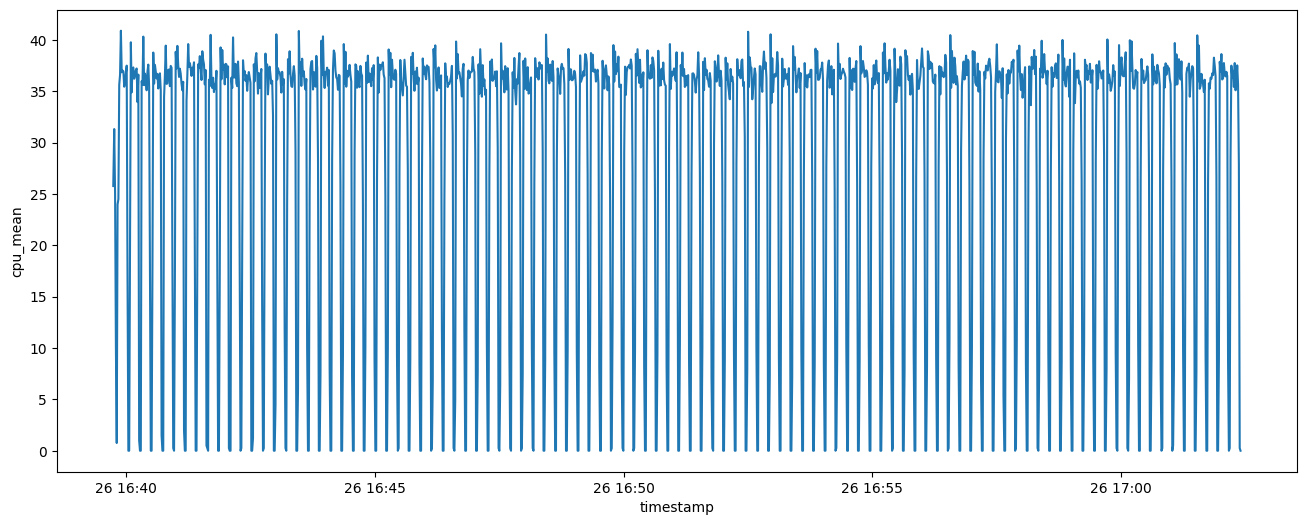

In [38]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx10_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

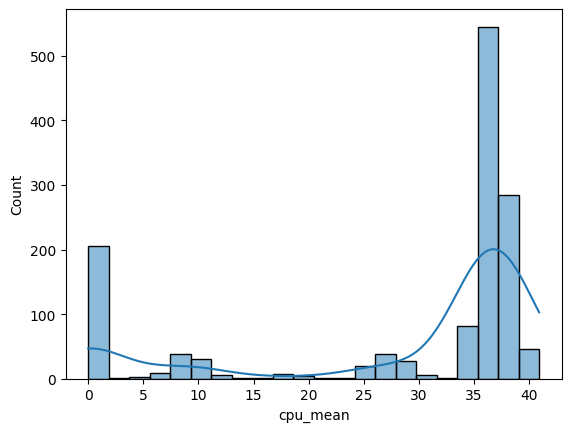

In [39]:
sns.histplot(data=dx10_cpu, x="cpu_mean", kde=True)
plt.show()

In [40]:
dx10_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1356,1356.000000,1356.00000,1356.000000,1356.000000,1356.000000
mean,2026-04-26 16:51:04.459000,26.426254,30.94705,30.621755,26.347861,28.585730
min,2026-04-26 16:39:44.152737,0.000000,0.00000,0.000000,0.000000,0.000000
25%,2026-04-26 16:45:24.308835,15.775000,17.20000,17.300000,16.300000,26.487500
50%,2026-04-26 16:51:04.490707,22.500000,28.20000,28.600000,22.200000,36.150000
75%,2026-04-26 16:56:44.615497,38.100000,45.90000,44.450000,39.000000,37.175000
max,2026-04-26 17:02:24.618409,92.900000,93.90000,98.000000,99.000000,40.900000
std,NaN,19.699525,22.11511,21.559065,19.299339,14.131987


In [133]:
threshold = dx10_cpu['cpu_mean'].quantile(0.75)
dx10_cpu[dx10_cpu['cpu_mean'] > threshold].describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,331,331.000000,331.000000,331.000000,331.000000,331.000000
mean,2026-04-26 16:51:08.408182,35.422659,42.300000,40.822659,33.949849,38.123792
min,2026-04-26 16:39:53.354965,17.200000,18.200000,17.500000,18.000000,37.175000
25%,2026-04-26 16:45:33.096147,22.400000,27.150000,27.000000,21.600000,37.462500
50%,2026-04-26 16:51:00.982377,30.400000,39.000000,37.800000,28.700000,37.875000
75%,2026-04-26 16:56:37.848980,44.600000,54.550000,50.000000,42.600000,38.625000
max,2026-04-26 17:02:20.610395,90.500000,93.900000,91.800000,82.700000,40.900000
std,NaN,15.877377,17.080833,16.853244,14.569762,0.850908


### RAM

In [41]:
dx10_ram = pd.read_csv(f'{x10_folder_path}/mem.csv')
dx10_ram['timestamp'] = dx10_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx10_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-26 16:39:43.151331,17002643456,16376643584,625999872,3.7,15793176576,720519168,185827328,39829504,661995520
1,2026-04-26 16:39:44.152329,17002643456,16335241216,667402240,3.9,15748448256,757399552,187039744,39845888,664846336
2,2026-04-26 16:39:45.315285,17002643456,16254500864,748142592,4.4,15667707904,825966592,187039744,39845888,664846336
3,2026-04-26 16:39:46.325713,17002643456,16178692096,823951360,4.8,15591768064,885686272,187039744,39845888,664977408
4,2026-04-26 16:39:47.326083,17002643456,16057712640,944930816,5.6,15410397184,1005912064,247414784,39845888,725565440


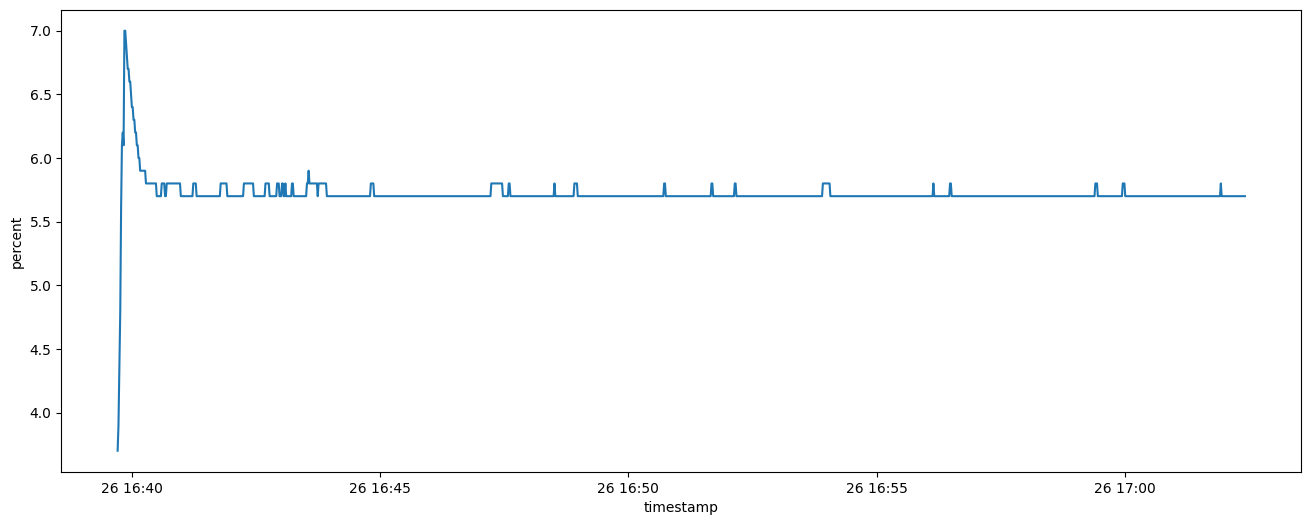

In [42]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx10_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

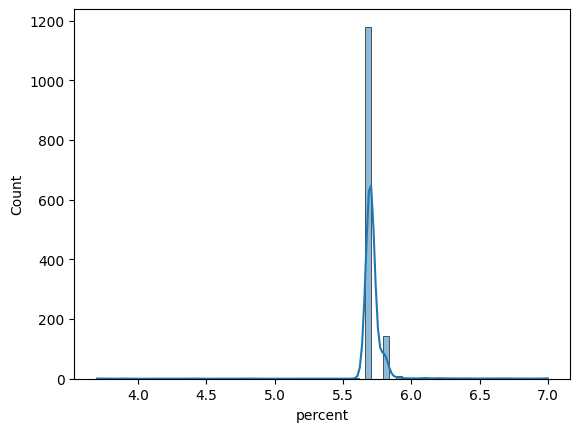

In [43]:
sns.histplot(data=dx10_ram, x="percent", kde=True)
plt.show()

In [44]:
dx10_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,1358,1.358000e+03,1.358000e+03,1.358000e+03,1358.000000,1.358000e+03,1.358000e+03,1.358000e+03,1.358000e+03,1.358000e+03
mean,2026-04-26 16:51:04.038977,1.700264e+10,1.602696e+10,9.756791e+08,5.718851,1.527836e+10,1.201994e+09,3.448744e+08,4.002039e+07,8.266195e+08
min,2026-04-26 16:39:43.151331,1.700264e+10,1.581880e+10,6.259999e+08,3.700000,1.506986e+10,7.205192e+08,1.858273e+08,3.982950e+07,6.619955e+08
25%,2026-04-26 16:45:23.433647,1.700264e+10,1.602717e+10,9.724068e+08,5.700000,1.527795e+10,1.202536e+09,3.452928e+08,3.989504e+07,8.271462e+08
50%,2026-04-26 16:51:03.967210,1.700264e+10,1.602904e+10,9.736028e+08,5.700000,1.527982e+10,1.204175e+09,3.453092e+08,3.991142e+07,8.271462e+08
75%,2026-04-26 16:56:44.620926,1.700264e+10,1.603024e+10,9.754706e+08,5.700000,1.528103e+10,1.204552e+09,3.456205e+08,4.022272e+07,8.272773e+08
max,2026-04-26 17:02:25.059728,1.700264e+10,1.637664e+10,1.183842e+09,7.000000,1.579318e+10,1.205420e+09,3.456369e+08,4.023910e+07,8.272937e+08
std,NaN,0.000000e+00,2.219197e+07,2.219197e+07,0.134579,2.881647e+07,2.386668e+07,9.002375e+06,1.620814e+05,9.257113e+06


In [134]:
threshold = dx10_ram['percent'].quantile(0.75)
dx10_ram[dx10_ram['percent'] > threshold].describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,173,1.730000e+02,1.730000e+02,1.730000e+02,173.000000,1.730000e+02,1.730000e+02,1.730000e+02,1.730000e+02,1.730000e+02
mean,2026-04-26 16:44:23.921641,1.700264e+10,1.600606e+10,9.965868e+08,5.883237,1.525711e+10,1.199994e+09,3.452883e+08,3.991985e+07,8.270352e+08
min,2026-04-26 16:39:48.326417,1.700264e+10,1.581880e+10,9.776660e+08,5.800000,1.506986e+10,9.963930e+08,3.414917e+08,3.986227e+07,8.200028e+08
25%,2026-04-26 16:40:37.432465,1.700264e+10,1.601392e+10,9.792881e+08,5.800000,1.526494e+10,1.201209e+09,3.452764e+08,3.987866e+07,8.270807e+08
50%,2026-04-26 16:42:26.725164,1.700264e+10,1.602113e+10,9.815163e+08,5.800000,1.527197e+10,1.202160e+09,3.452764e+08,3.987866e+07,8.270807e+08
75%,2026-04-26 16:47:16.583113,1.700264e+10,1.602336e+10,9.887252e+08,5.800000,1.527433e+10,1.203143e+09,3.452928e+08,3.989504e+07,8.271462e+08
max,2026-04-26 17:01:55.962980,1.700264e+10,1.602498e+10,1.183842e+09,7.000000,1.527597e+10,1.205420e+09,3.456369e+08,4.023910e+07,8.272773e+08
std,NaN,0.000000e+00,4.112178e+07,4.112178e+07,0.235033,4.100315e+07,1.833142e+07,3.150799e+05,1.092179e+05,6.734543e+05


### Power

In [45]:
dx10_power = pd.read_csv(f'{x10_folder_path}/power.csv')
dx10_power['timestamp'] = dx10_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx10_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-29T08:16:26.874111,0.0,5.1092,0.64557,3.2924,2026-04-29 08:16:26.874111
1,2026-04-29T08:16:27.847860,1.0,5.1119,0.68646,3.5078,2026-04-29 08:16:27.847860
2,2026-04-29T08:16:28.866304,2.0,5.1114,0.74619,3.8130,2026-04-29 08:16:28.866304
3,2026-04-29T08:16:29.837922,3.0,5.1092,0.75191,3.8347,2026-04-29 08:16:29.837922
4,2026-04-29T08:16:30.857400,4.0,5.1088,0.77526,3.9538,2026-04-29 08:16:30.857400


In [46]:
dx10_power = dx10_power.sort_values('timestamp')

# Time difference in hours
dx10_power['dt_hours'] = dx10_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx10_power['energy_Wh'] = dx10_power['Power[W]'] * dx10_power['dt_hours']

# Total energy
total_energy_Wh = dx10_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.8276234670439724
Total energy (kWh): 0.0018276234670439723


In [47]:
dx10_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,1376.000000,1376.000000,1376.000000,1376.000000,1376,1375.000000,1375.000000
mean,687.621439,5.107903,0.937357,4.782357,2026-04-29 08:27:54.480552,0.000278,0.001329
min,0.000000,5.090800,0.510180,2.601900,2026-04-29 08:16:26.874111,0.000269,0.000704
25%,343.850000,5.106100,0.879385,4.484775,2026-04-29 08:22:10.657527,0.000271,0.001229
50%,687.600000,5.108400,0.975520,4.975500,2026-04-29 08:27:54.487513,0.000283,0.001383
75%,1031.450000,5.109900,1.055125,5.380725,2026-04-29 08:33:38.294284,0.000284,0.001496
max,1375.200000,5.121700,1.415560,7.219300,2026-04-29 08:39:22.123823,0.000285,0.002042
std,397.430159,0.004277,0.180787,0.922797,NaN,0.000006,0.000259


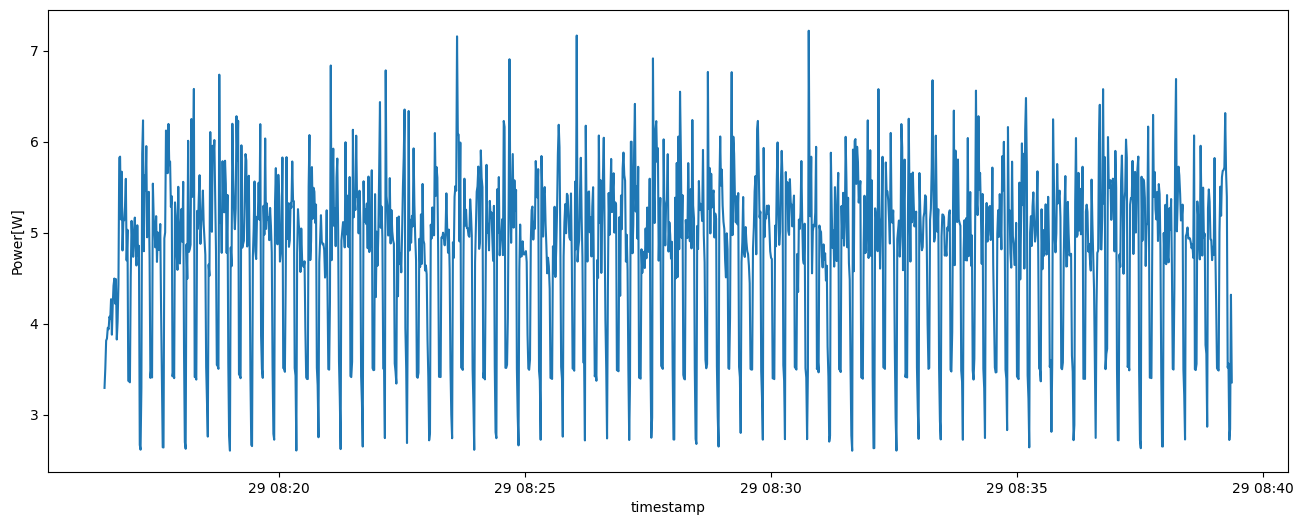

In [48]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx10_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

In [3]:
import pandas as pd
import numpy  as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

## X2.0 ~ Baseline

passage_time: 10; interval: 3; window: 3

In [122]:
x20_folder_path = '../infra/reports/batch_baseline'

### Predict

In [8]:
from pandas import json_normalize
import json

with open(f'{x20_folder_path}/metrics.json') as f:
    x20_data = json.load(f)

load_model_duration = datetime.fromisoformat(x20_data['load_model_final']) - datetime.fromisoformat(x20_data['load_model_start'])
    
rows = []
for animal, v1 in x20_data['animals'].items():
    row = {
        'pid': x20_data['pid'],
        'load_model_start': datetime.fromisoformat(x20_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x20_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],
    }
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx20_metrics_v0 = pd.DataFrame.from_dict(rows)
dx20_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,1,2026-04-17 16:34:48.498905,2026-04-17 16:34:58.398448,2026-04-17 16:35:00.646093,11,3,2026-04-17 16:34:59.360526,2026-04-17 16:35:00.646012
1,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,2,2026-04-17 16:35:03.646204,2026-04-17 16:35:13.411903,2026-04-17 16:35:15.892372,11,4,2026-04-17 16:35:14.381794,2026-04-17 16:35:15.892298
2,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,3,2026-04-17 16:35:18.894002,2026-04-17 16:35:28.642804,2026-04-17 16:35:31.124555,11,4,2026-04-17 16:35:29.619902,2026-04-17 16:35:31.124492
3,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,4,2026-04-17 16:35:34.126128,2026-04-17 16:35:43.882998,2026-04-17 16:35:46.365044,11,4,2026-04-17 16:35:44.859654,2026-04-17 16:35:46.364982
4,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,5,2026-04-17 16:35:49.366634,2026-04-17 16:35:59.101561,2026-04-17 16:36:01.584840,11,4,2026-04-17 16:36:00.081610,2026-04-17 16:36:01.584772


In [9]:
dx20_metrics_v0['by_animal_lead_time'] = dx20_metrics_v0['display_time'] - dx20_metrics_v0['first_image_capture_time']
dx20_metrics_v0['by_animal_processing_delay'] = dx20_metrics_v0['weight_prediction_final'] - dx20_metrics_v0['weight_prediction_start']
dx20_metrics_v0['by_animal_latency'] = dx20_metrics_v0['display_time'] - dx20_metrics_v0['last_image_capture_time']

dx20_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,1,2026-04-17 16:34:48.498905,2026-04-17 16:34:58.398448,2026-04-17 16:35:00.646093,11,3,2026-04-17 16:34:59.360526,2026-04-17 16:35:00.646012,0 days 00:00:12.147188,0 days 00:00:01.285486,0 days 00:00:02.247645
1,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,2,2026-04-17 16:35:03.646204,2026-04-17 16:35:13.411903,2026-04-17 16:35:15.892372,11,4,2026-04-17 16:35:14.381794,2026-04-17 16:35:15.892298,0 days 00:00:12.246168,0 days 00:00:01.510504,0 days 00:00:02.480469
2,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,3,2026-04-17 16:35:18.894002,2026-04-17 16:35:28.642804,2026-04-17 16:35:31.124555,11,4,2026-04-17 16:35:29.619902,2026-04-17 16:35:31.124492,0 days 00:00:12.230553,0 days 00:00:01.504590,0 days 00:00:02.481751
3,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,4,2026-04-17 16:35:34.126128,2026-04-17 16:35:43.882998,2026-04-17 16:35:46.365044,11,4,2026-04-17 16:35:44.859654,2026-04-17 16:35:46.364982,0 days 00:00:12.238916,0 days 00:00:01.505328,0 days 00:00:02.482046
4,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,5,2026-04-17 16:35:49.366634,2026-04-17 16:35:59.101561,2026-04-17 16:36:01.584840,11,4,2026-04-17 16:36:00.081610,2026-04-17 16:36:01.584772,0 days 00:00:12.218206,0 days 00:00:01.503162,0 days 00:00:02.483279


In [10]:
collect_lead_time = dx20_metrics_v0['display_time'].max() - dx20_metrics_v0['first_image_capture_time'].min()
qtt = len(dx20_metrics_v0['animal'].unique())

dx20_metrics_v0['collect_lead_time'] = collect_lead_time
dx20_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx20_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,1,2026-04-17 16:34:48.498905,2026-04-17 16:34:58.398448,2026-04-17 16:35:00.646093,11,3,2026-04-17 16:34:59.360526,2026-04-17 16:35:00.646012,0 days 00:00:12.147188,0 days 00:00:01.285486,0 days 00:00:02.247645,0 days 00:25:16.521960,237.385287
1,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,2,2026-04-17 16:35:03.646204,2026-04-17 16:35:13.411903,2026-04-17 16:35:15.892372,11,4,2026-04-17 16:35:14.381794,2026-04-17 16:35:15.892298,0 days 00:00:12.246168,0 days 00:00:01.510504,0 days 00:00:02.480469,0 days 00:25:16.521960,237.385287
2,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,3,2026-04-17 16:35:18.894002,2026-04-17 16:35:28.642804,2026-04-17 16:35:31.124555,11,4,2026-04-17 16:35:29.619902,2026-04-17 16:35:31.124492,0 days 00:00:12.230553,0 days 00:00:01.504590,0 days 00:00:02.481751,0 days 00:25:16.521960,237.385287
3,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,4,2026-04-17 16:35:34.126128,2026-04-17 16:35:43.882998,2026-04-17 16:35:46.365044,11,4,2026-04-17 16:35:44.859654,2026-04-17 16:35:46.364982,0 days 00:00:12.238916,0 days 00:00:01.505328,0 days 00:00:02.482046,0 days 00:25:16.521960,237.385287
4,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,5,2026-04-17 16:35:49.366634,2026-04-17 16:35:59.101561,2026-04-17 16:36:01.584840,11,4,2026-04-17 16:36:00.081610,2026-04-17 16:36:01.584772,0 days 00:00:12.218206,0 days 00:00:01.503162,0 days 00:00:02.483279,0 days 00:25:16.521960,237.385287


In [11]:
dx20_metrics_v0.describe()

,load_model_start,load_model_final,load_model_dur,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,100,100,100,100,100,100,100.0,100.00,100,100,100,100,100,100,1.000000e+02
mean,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498784,0 days 00:00:06.966978,2026-04-17 16:47:20.835705,2026-04-17 16:47:30.559954,2026-04-17 16:47:33.029374,11.0,3.99,2026-04-17 16:47:31.525159,2026-04-17 16:47:33.029308,0 days 00:00:12.193669,0 days 00:00:01.504148,0 days 00:00:02.469420,0 days 00:25:16.521960,2.373853e+02
min,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,2026-04-17 16:34:48.498905,2026-04-17 16:34:58.398448,2026-04-17 16:35:00.646093,11.0,3.00,2026-04-17 16:34:59.360526,2026-04-17 16:35:00.646012,0 days 00:00:12.147188,0 days 00:00:01.285486,0 days 00:00:02.247645,0 days 00:25:16.521960,2.373853e+02
25%,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,2026-04-17 16:41:04.822626,2026-04-17 16:41:14.532290,2026-04-17 16:41:16.998775,11.0,4.00,2026-04-17 16:41:15.496319,2026-04-17 16:41:16.998706,0 days 00:00:12.180600,0 days 00:00:01.502726,0 days 00:00:02.464826,0 days 00:25:16.521960,2.373853e+02
50%,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,2026-04-17 16:47:20.826878,2026-04-17 16:47:30.580532,2026-04-17 16:47:33.048067,11.0,4.00,2026-04-17 16:47:31.542196,2026-04-17 16:47:33.048002,0 days 00:00:12.189137,0 days 00:00:01.504735,0 days 00:00:02.469943,0 days 00:25:16.521960,2.373853e+02
75%,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,2026-04-17 16:53:36.897586,2026-04-17 16:53:46.599645,2026-04-17 16:53:49.078583,11.0,4.00,2026-04-17 16:53:47.563127,2026-04-17 16:53:49.078519,0 days 00:00:12.206204,0 days 00:00:01.509799,0 days 00:00:02.479028,0 days 00:25:16.521960,2.373853e+02
max,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,2026-04-17 16:59:52.851947,2026-04-17 17:00:02.556852,2026-04-17 17:00:05.020865,11.0,4.00,2026-04-17 17:00:03.516983,2026-04-17 17:00:05.020799,0 days 00:00:12.246168,0 days 00:00:01.519931,0 days 00:00:02.493747,0 days 00:25:16.521960,2.373853e+02
std,NaN,NaN,0 days 00:00:00,NaN,NaN,NaN,0.0,0.10,NaN,NaN,0 days 00:00:00.019387,0 days 00:00:00.022677,0 days 00:00:00.023838,0 days 00:00:00,5.712979e-14


In [12]:
dx20_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:02:30.414880')

In [13]:
total_of_imgs = dx20_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx20_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 1100 - Time: 0 days 00:25:16.521960 => FPS:0.7253439310565605


### CPU

In [149]:
dx20_cpu = pd.read_csv(f'{x20_folder_path}/cpu.csv')

dx20_cpu['arch-str']  = 'seq-batch'
dx20_cpu['timestamp'] = dx20_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx20_cpu['cpu_mean']  = dx20_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx20_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,arch-str,cpu_mean
0,2026-04-17 16:34:42.534646,2.0,2.0,76.2,22.8,seq-batch,25.750
1,2026-04-17 16:34:43.560121,10.0,18.2,48.0,46.5,seq-batch,30.675
2,2026-04-17 16:34:44.596696,1.0,0.0,0.0,99.0,seq-batch,25.000
3,2026-04-17 16:34:45.597138,1.0,1.0,1.0,48.5,seq-batch,12.875
4,2026-04-17 16:34:46.597574,0.0,0.0,0.0,3.0,seq-batch,0.750


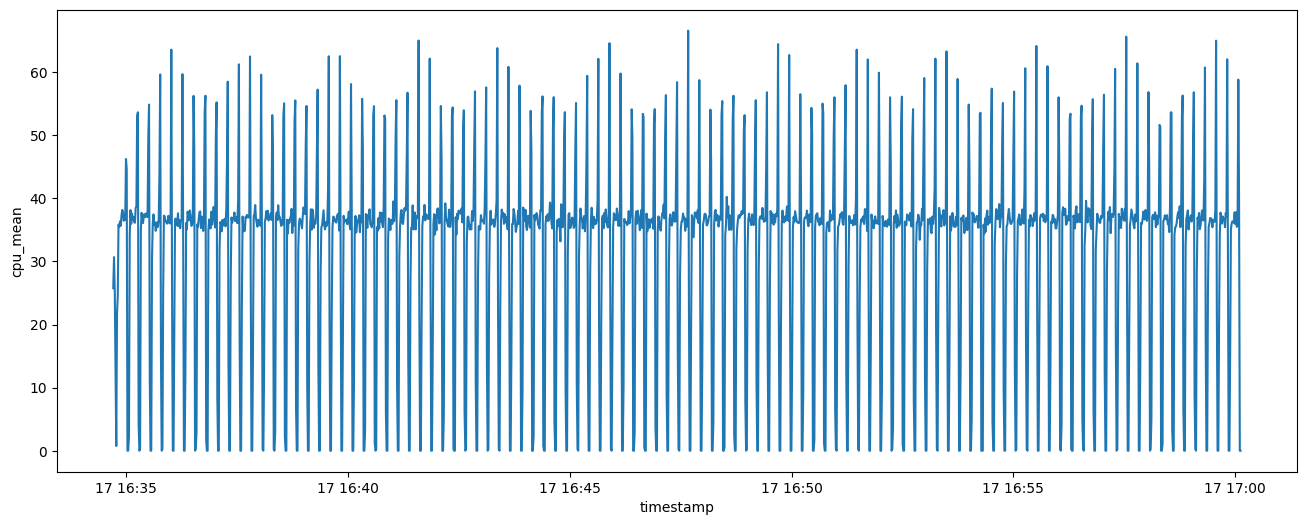

In [142]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx20_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

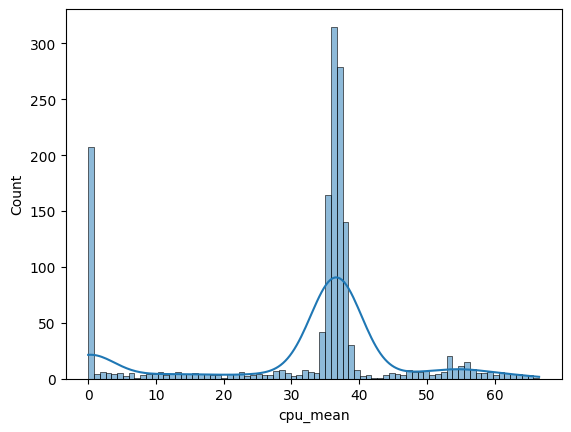

In [125]:
sns.histplot(data=dx20_cpu, x="cpu_mean", kde=True)
plt.show()

In [126]:
dx20_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1519,1519.000000,1519.000000,1519.000000,1519.000000,1519.000000
mean,2026-04-17 16:47:25.011924,29.779065,33.711389,33.259908,29.670770,31.605283
min,2026-04-17 16:34:42.534646,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-04-17 16:41:03.919286,17.300000,18.200000,18.000000,17.500000,34.487500
50%,2026-04-17 16:47:25.127266,25.000000,33.000000,31.000000,25.500000,36.350000
75%,2026-04-17 16:53:46.095597,44.400000,51.000000,50.500000,43.900000,37.425000
max,2026-04-17 17:00:07.279818,91.000000,92.800000,94.800000,99.000000,66.550000
std,NaN,20.731694,22.387042,22.324588,20.473336,15.597496


In [127]:
threshold = dx20_cpu['cpu_mean'].quantile(0.75)
dx20_cpu[dx20_cpu['cpu_mean'] > threshold].describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,379,379.000000,379.000000,379.000000,379.000000,379.000000
mean,2026-04-17 16:47:20.190540,43.194459,48.386280,46.235356,42.954090,45.192546
min,2026-04-17 16:34:54.717692,18.000000,16.200000,18.200000,18.200000,37.425000
25%,2026-04-17 16:41:20.002796,24.900000,35.300000,32.150000,26.450000,37.875000
50%,2026-04-17 16:46:54.918826,43.600000,50.000000,46.900000,44.000000,38.725000
75%,2026-04-17 16:53:41.083479,56.950000,60.100000,58.000000,54.000000,53.575000
max,2026-04-17 17:00:05.277747,91.000000,92.800000,94.800000,92.700000,66.550000
std,NaN,17.687559,17.342822,16.850446,16.896092,8.841889


### RAM

In [128]:
dx20_ram = pd.read_csv(f'{x20_folder_path}/mem.csv')
dx20_ram['timestamp'] = dx20_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx20_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-17 16:34:41.532007,17006837760,16469524480,537313280,3.2,15861399552,734216192,195411968,40009728,686686208
1,2026-04-17 16:34:42.534420,17006837760,16431136768,575700992,3.4,15820341248,769933312,196427776,40009728,689242112
2,2026-04-17 16:34:43.570458,17006837760,16323985408,682852352,4.0,15713189888,838500352,196427776,40009728,689242112
3,2026-04-17 16:34:44.575800,17006837760,16286515200,720322560,4.2,15675588608,877592576,196427776,40009728,689373184
4,2026-04-17 16:34:45.576143,17006837760,16125476864,881360896,5.2,15464497152,1008222208,246480896,40009728,739459072


In [140]:
load_model_date = dx20_metrics_v0['load_model_start'].min()
dx20_ram['status'] = dx20_ram['timestamp'].apply(lambda x: 'in' if x >= load_model_date else 'off')
dx20_ram.groupby('status').size()#head()

status
in    1522
dtype: int64

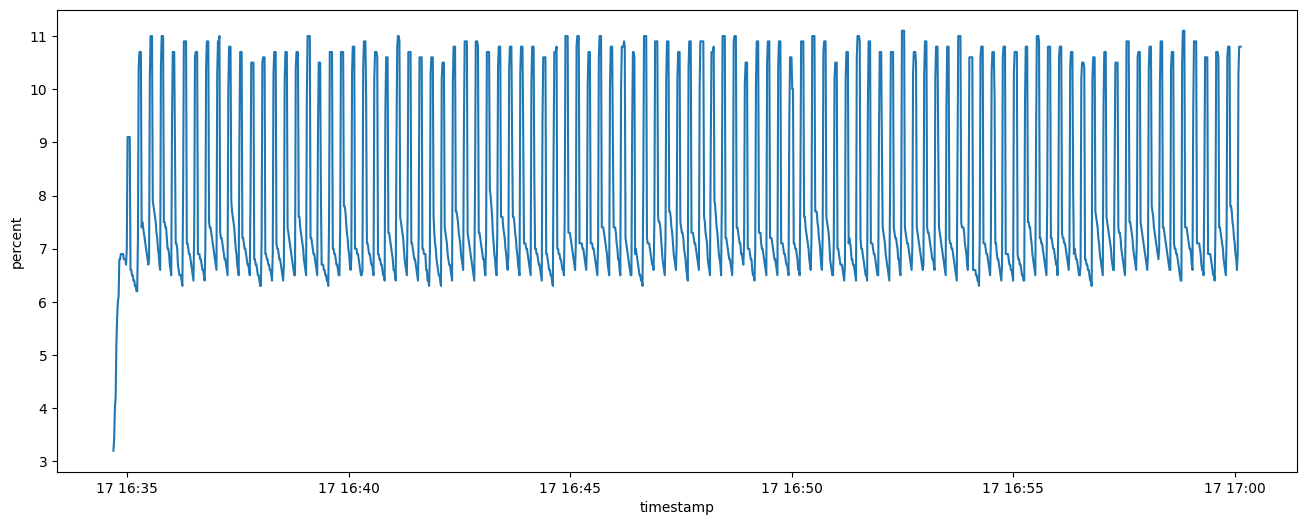

In [129]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx20_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

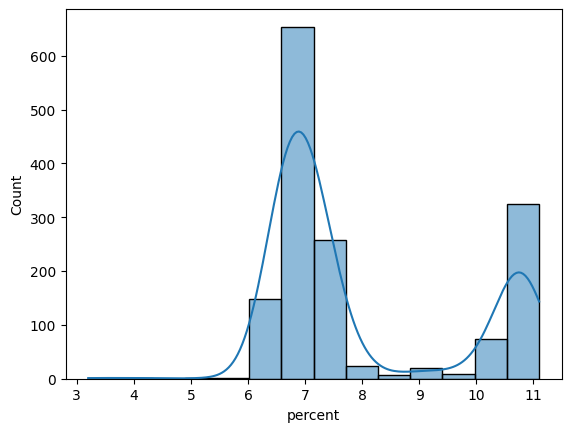

In [130]:
sns.histplot(data=dx20_ram, x="percent", kde=True)
plt.show()

In [131]:
dx20_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,1522,1.522000e+03,1.522000e+03,1.522000e+03,1522.000000,1.522000e+03,1.522000e+03,1.522000e+03,1.522000e+03,1.522000e+03
mean,2026-04-17 16:47:24.704237,1.700684e+10,1.565262e+10,1.354222e+09,7.964192,1.487978e+10,1.409544e+09,3.544031e+08,4.027836e+07,8.511137e+08
min,2026-04-17 16:34:41.532007,1.700684e+10,1.512151e+10,5.373133e+08,3.200000,1.434788e+10,7.342162e+08,1.954120e+08,4.000973e+07,6.866862e+08
25%,2026-04-17 16:41:03.096590,1.700684e+10,1.527463e+10,1.148158e+09,6.800000,1.450102e+10,1.216217e+09,3.546644e+08,4.004250e+07,8.515584e+08
50%,2026-04-17 16:47:24.709078,1.700684e+10,1.579889e+10,1.207951e+09,7.100000,1.502554e+10,1.218904e+09,3.551068e+08,4.048486e+07,8.517059e+08
75%,2026-04-17 16:53:46.235658,1.700684e+10,1.585868e+10,1.732211e+09,10.200000,1.508523e+10,1.830240e+09,3.551232e+08,4.050125e+07,8.517059e+08
max,2026-04-17 17:00:07.876060,1.700684e+10,1.646952e+10,1.885323e+09,11.100000,1.586140e+10,1.915191e+09,3.551396e+08,4.051763e+07,8.517059e+08
std,NaN,0.000000e+00,2.909347e+08,2.909347e+08,1.711603,2.922846e+08,2.987134e+08,8.598059e+06,2.297243e+05,8.837901e+06


In [132]:
threshold = dx20_ram['percent'].quantile(0.75)
dx20_ram[dx20_ram['percent'] > threshold].describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,374,3.740000e+02,3.740000e+02,3.740000e+02,374.000000,3.740000e+02,3.740000e+02,3.740000e+02,3.740000e+02,3.740000e+02
mean,2026-04-17 16:47:48.915814,1.700684e+10,1.517838e+10,1.828454e+09,10.754545,1.440502e+10,1.899415e+09,3.549071e+08,4.028532e+07,8.516353e+08
min,2026-04-17 16:35:15.767564,1.700684e+10,1.512151e+10,1.744142e+09,10.300000,1.434788e+10,1.808646e+09,3.546644e+08,4.004250e+07,8.515584e+08
25%,2026-04-17 16:41:36.215426,1.700684e+10,1.515402e+10,1.811841e+09,10.700000,1.438045e+10,1.904099e+09,3.546644e+08,4.004250e+07,8.515584e+08
50%,2026-04-17 16:47:56.820872,1.700684e+10,1.517719e+10,1.829650e+09,10.800000,1.440404e+10,1.906541e+09,3.551068e+08,4.048486e+07,8.517059e+08
75%,2026-04-17 16:54:04.309475,1.700684e+10,1.519500e+10,1.852817e+09,10.900000,1.442173e+10,1.908662e+09,3.551232e+08,4.050125e+07,8.517059e+08
max,2026-04-17 17:00:07.876060,1.700684e+10,1.526270e+10,1.885323e+09,11.100000,1.448962e+10,1.915191e+09,3.551396e+08,4.051763e+07,8.517059e+08
std,NaN,0.000000e+00,3.027671e+07,3.027671e+07,0.180313,3.028954e+07,2.274854e+07,2.298037e+05,2.296692e+05,7.375918e+04


### Power

In [214]:
dx20_power = pd.read_csv(f'{x20_folder_path}/power.csv')
dx20_power['timestamp'] = dx20_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx20_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-17T16:34:31.155259,0.0,5.1096,0.55546,2.8328,2026-04-17 16:34:31.155259
1,2026-04-17T16:34:32.122710,1.0,5.1096,0.58730,2.9952,2026-04-17 16:34:32.122710
2,2026-04-17T16:34:33.139966,2.0,5.1094,0.77582,3.9566,2026-04-17 16:34:33.139966
3,2026-04-17T16:34:34.159820,3.0,5.1092,0.77238,3.9391,2026-04-17 16:34:34.159820
4,2026-04-17T16:34:35.131664,4.0,5.1089,0.77649,3.9600,2026-04-17 16:34:35.131664


In [18]:
dx20_power = dx20_power.sort_values('timestamp')

# Time difference in hours
dx20_power['dt_hours'] = dx20_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx20_power['energy_Wh'] = dx20_power['Power[W]'] * dx20_power['dt_hours']

# Total energy
total_energy_Wh = dx20_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 2.3209750335498054
Total energy (kWh): 0.0023209750335498056


In [19]:
dx20_power.describe()

,Time[S],Volt[V],Current[A],Power[W],dt_hours,energy_Wh
count,1540.000000,1540.000000,1540.000000,1540.000000,1539.000000,1539.000000
mean,769.584416,5.107147,1.063958,5.427610,0.000278,0.001508
std,444.761783,0.004575,0.183448,0.936051,0.000006,0.000260
min,0.000000,5.086400,0.555460,2.832800,0.000269,0.000805
25%,384.750000,5.105300,1.003973,5.120425,0.000271,0.001404
50%,769.600000,5.107900,1.081880,5.522850,0.000283,0.001537
75%,1154.350000,5.109400,1.165470,5.946800,0.000283,0.001665
max,1539.200000,5.123300,1.802780,9.212200,0.000285,0.002569


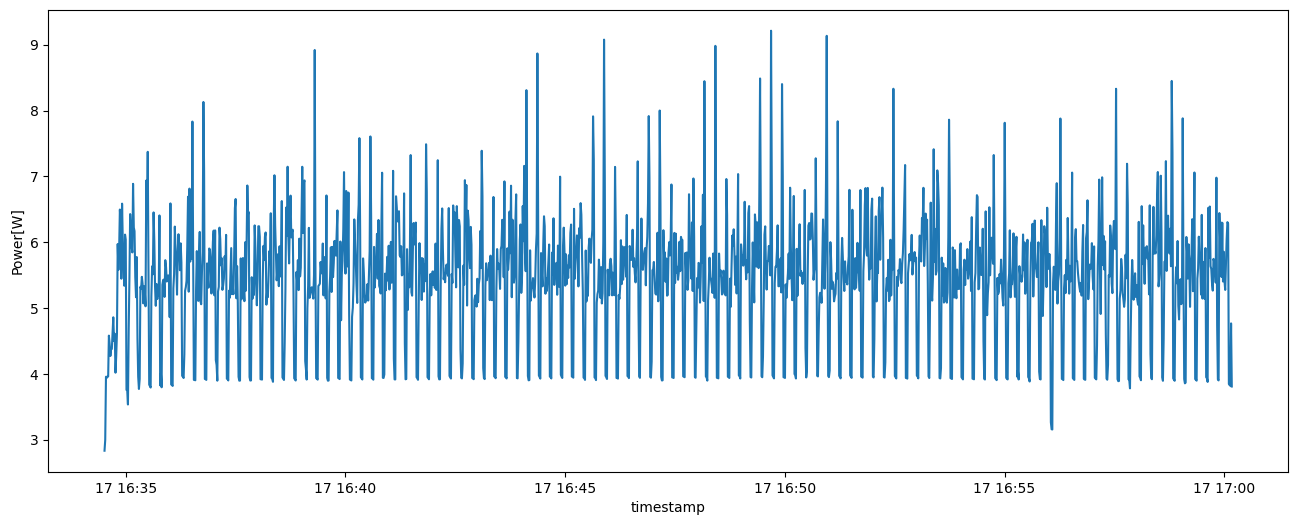

In [20]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx20_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

## X2.1

passage_time: 5; interval: 3; window: 3

In [78]:
x21_folder_path = '../infra/reports/batch_x21'

### Predict

In [79]:
from pandas import json_normalize
import json

with open(f'{x21_folder_path}/metrics.json') as f:
    x21_data = json.load(f)

load_model_duration = datetime.fromisoformat(x21_data['load_model_final']) - datetime.fromisoformat(x21_data['load_model_start'])
    
rows = []
for animal, v1 in x21_data['animals'].items():
    row = {
        'pid': x21_data['pid'],
        'load_model_start': datetime.fromisoformat(x21_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x21_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],    
    }
    
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx21_metrics_v0 = pd.DataFrame.from_dict(rows)
dx21_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,1,2026-04-17 17:05:57.231821,2026-04-17 17:06:01.410884,2026-04-17 17:06:03.742907,5,3,2026-04-17 17:06:02.419459,2026-04-17 17:06:03.742819
1,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2,2026-04-17 17:06:06.743041,2026-04-17 17:06:10.796294,2026-04-17 17:06:13.081174,5,3,2026-04-17 17:06:11.784023,2026-04-17 17:06:13.081105
2,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,3,2026-04-17 17:06:16.082067,2026-04-17 17:06:20.091644,2026-04-17 17:06:22.441256,5,3,2026-04-17 17:06:21.102229,2026-04-17 17:06:22.441184
3,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,4,2026-04-17 17:06:25.442878,2026-04-17 17:06:29.477876,2026-04-17 17:06:31.790001,5,3,2026-04-17 17:06:30.485137,2026-04-17 17:06:31.789921
4,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,5,2026-04-17 17:06:34.791963,2026-04-17 17:06:38.816524,2026-04-17 17:06:41.118891,5,3,2026-04-17 17:06:39.809684,2026-04-17 17:06:41.118814


In [80]:
dx21_metrics_v0['by_animal_lead_time'] = dx21_metrics_v0['display_time'] - dx21_metrics_v0['first_image_capture_time']
dx21_metrics_v0['by_animal_processing_delay'] = dx21_metrics_v0['weight_prediction_final'] - dx21_metrics_v0['weight_prediction_start']
dx21_metrics_v0['by_animal_latency'] = dx21_metrics_v0['display_time'] - dx21_metrics_v0['last_image_capture_time']

dx21_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,1,2026-04-17 17:05:57.231821,2026-04-17 17:06:01.410884,2026-04-17 17:06:03.742907,5,3,2026-04-17 17:06:02.419459,2026-04-17 17:06:03.742819,0 days 00:00:06.511086,0 days 00:00:01.323360,0 days 00:00:02.332023
1,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2,2026-04-17 17:06:06.743041,2026-04-17 17:06:10.796294,2026-04-17 17:06:13.081174,5,3,2026-04-17 17:06:11.784023,2026-04-17 17:06:13.081105,0 days 00:00:06.338133,0 days 00:00:01.297082,0 days 00:00:02.284880
2,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,3,2026-04-17 17:06:16.082067,2026-04-17 17:06:20.091644,2026-04-17 17:06:22.441256,5,3,2026-04-17 17:06:21.102229,2026-04-17 17:06:22.441184,0 days 00:00:06.359189,0 days 00:00:01.338955,0 days 00:00:02.349612
3,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,4,2026-04-17 17:06:25.442878,2026-04-17 17:06:29.477876,2026-04-17 17:06:31.790001,5,3,2026-04-17 17:06:30.485137,2026-04-17 17:06:31.789921,0 days 00:00:06.347123,0 days 00:00:01.304784,0 days 00:00:02.312125
4,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,5,2026-04-17 17:06:34.791963,2026-04-17 17:06:38.816524,2026-04-17 17:06:41.118891,5,3,2026-04-17 17:06:39.809684,2026-04-17 17:06:41.118814,0 days 00:00:06.326928,0 days 00:00:01.309130,0 days 00:00:02.302367


In [81]:
collect_lead_time = dx21_metrics_v0['display_time'].max() - dx21_metrics_v0['first_image_capture_time'].min()
qtt = len(dx21_metrics_v0['animal'].unique())

dx21_metrics_v0['collect_lead_time'] = collect_lead_time
dx21_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx21_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,1,2026-04-17 17:05:57.231821,2026-04-17 17:06:01.410884,2026-04-17 17:06:03.742907,5,3,2026-04-17 17:06:02.419459,2026-04-17 17:06:03.742819,0 days 00:00:06.511086,0 days 00:00:01.323360,0 days 00:00:02.332023,0 days 00:15:39.570844,383.153652
1,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2,2026-04-17 17:06:06.743041,2026-04-17 17:06:10.796294,2026-04-17 17:06:13.081174,5,3,2026-04-17 17:06:11.784023,2026-04-17 17:06:13.081105,0 days 00:00:06.338133,0 days 00:00:01.297082,0 days 00:00:02.284880,0 days 00:15:39.570844,383.153652
2,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,3,2026-04-17 17:06:16.082067,2026-04-17 17:06:20.091644,2026-04-17 17:06:22.441256,5,3,2026-04-17 17:06:21.102229,2026-04-17 17:06:22.441184,0 days 00:00:06.359189,0 days 00:00:01.338955,0 days 00:00:02.349612,0 days 00:15:39.570844,383.153652
3,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,4,2026-04-17 17:06:25.442878,2026-04-17 17:06:29.477876,2026-04-17 17:06:31.790001,5,3,2026-04-17 17:06:30.485137,2026-04-17 17:06:31.789921,0 days 00:00:06.347123,0 days 00:00:01.304784,0 days 00:00:02.312125,0 days 00:15:39.570844,383.153652
4,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,5,2026-04-17 17:06:34.791963,2026-04-17 17:06:38.816524,2026-04-17 17:06:41.118891,5,3,2026-04-17 17:06:39.809684,2026-04-17 17:06:41.118814,0 days 00:00:06.326928,0 days 00:00:01.309130,0 days 00:00:02.302367,0 days 00:15:39.570844,383.153652


In [82]:
dx21_metrics_v0.describe()

,load_model_dur,total_of_images,suitable_images,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,100,100.000000,100.000000,100,100,100,100,1.000000e+02
mean,0 days 00:00:07.027009,5.050000,3.030000,0 days 00:00:06.424034540,0 days 00:00:01.325684200,0 days 00:00:02.326210720,0 days 00:15:39.570844,3.831537e+02
std,0 days 00:00:00,0.219043,0.171447,0 days 00:00:00.237602985,0 days 00:00:00.037659547,0 days 00:00:00.040480679,0 days 00:00:00,1.142596e-13
min,0 days 00:00:07.027009,5.000000,3.000000,0 days 00:00:06.308333,0 days 00:00:01.295961,0 days 00:00:02.274947,0 days 00:15:39.570844,3.831537e+02
25%,0 days 00:00:07.027009,5.000000,3.000000,0 days 00:00:06.352670,0 days 00:00:01.312570250,0 days 00:00:02.311899500,0 days 00:15:39.570844,3.831537e+02
50%,0 days 00:00:07.027009,5.000000,3.000000,0 days 00:00:06.375167500,0 days 00:00:01.319465,0 days 00:00:02.320001500,0 days 00:15:39.570844,3.831537e+02
75%,0 days 00:00:07.027009,5.000000,3.000000,0 days 00:00:06.388513500,0 days 00:00:01.328601500,0 days 00:00:02.332950500,0 days 00:15:39.570844,3.831537e+02
max,0 days 00:00:07.027009,6.000000,4.000000,0 days 00:00:07.541387,0 days 00:00:01.540708,0 days 00:00:02.542671,0 days 00:15:39.570844,3.831537e+02


In [83]:
dx21_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:02:12.568420')

In [27]:
total_of_imgs = dx21_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx21_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 505 - Time: 0 days 00:15:39.570844 => FPS:0.5374794282143561


### CPU

In [28]:
dx21_cpu = pd.read_csv(f'{x21_folder_path}/cpu.csv')

dx21_cpu['timestamp'] = dx21_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx21_cpu['cpu_mean']  = dx21_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx21_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-17 17:05:51.205827,2.0,2.0,95.0,2.0,25.250
1,2026-04-17 17:05:52.236993,34.7,15.8,28.4,46.6,31.375
2,2026-04-17 17:05:53.403491,100.0,0.9,0.9,1.7,25.875
3,2026-04-17 17:05:54.404129,35.0,1.0,1.0,0.0,9.250
4,2026-04-17 17:05:55.404549,4.0,0.0,0.0,1.0,1.250


In [29]:
dx21_cpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,946.000000,946.000000,946.000000,946.000000,946.000000
mean,27.042178,28.093129,28.242495,24.538161,26.978990
std,23.262456,23.723330,23.637107,20.649589,17.629036
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,3.000000,4.000000,5.000000,5.868750
50%,21.200000,23.800000,23.600000,20.000000,35.400000
75%,43.900000,45.750000,45.400000,39.200000,37.075000
max,100.000000,93.800000,95.000000,92.900000,61.275000


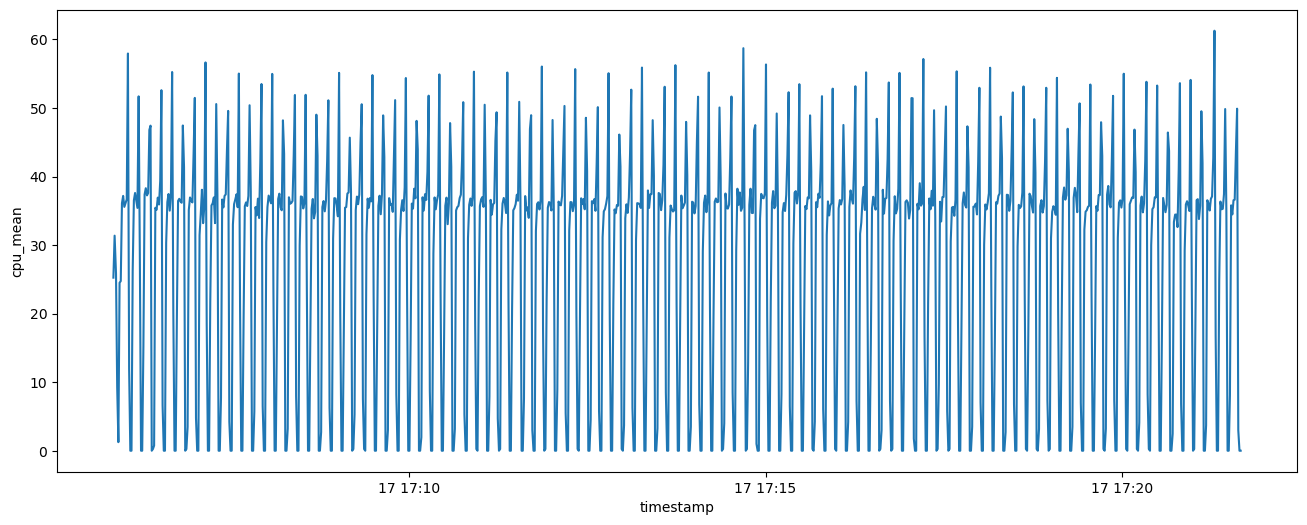

In [30]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx21_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

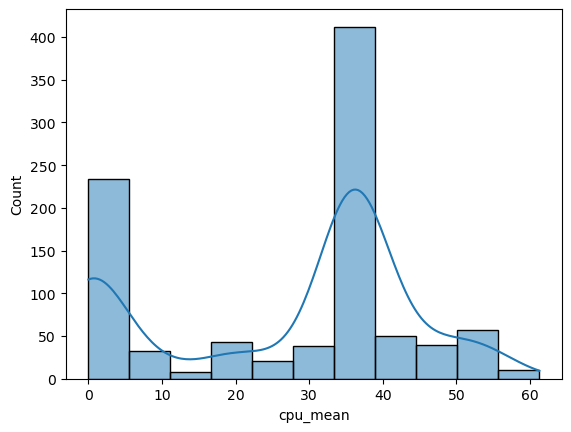

In [31]:
sns.histplot(data=dx21_cpu, x="cpu_mean", kde=True)
plt.show()

### RAM

In [32]:
dx21_ram = pd.read_csv(f'{x21_folder_path}/mem.csv')
dx21_ram['timestamp'] = dx21_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx21_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-17 17:05:50.205030,17002643456,16456679424,545964032,3.2,15874048000,720666624,184582144,38502400,661913600
1,2026-04-17 17:05:51.205898,17002643456,16418570240,584073216,3.4,15833497600,756088832,185384960,38502400,664436736
2,2026-04-17 17:05:52.221525,17002643456,16327884800,674758656,4.0,15742812160,825163776,185384960,38502400,664436736
3,2026-04-17 17:05:53.221838,17002643456,16275423232,727220224,4.3,15690219520,859160576,185384960,38502400,664567808
4,2026-04-17 17:05:54.222319,17002643456,16103407616,899235840,5.3,15471001600,991674368,232570880,38502400,712048640


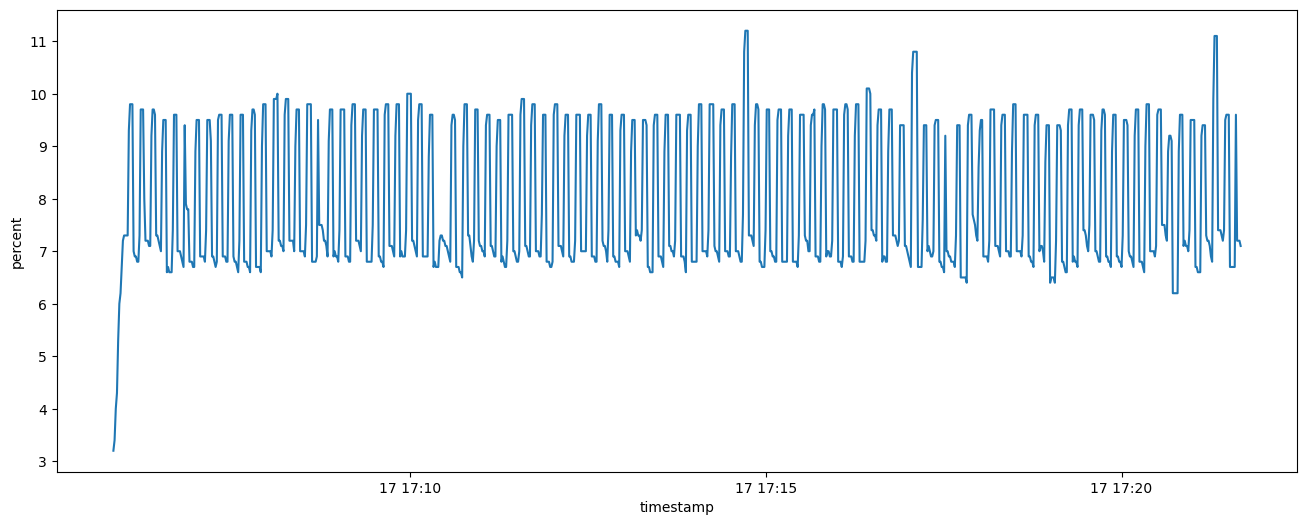

In [33]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx21_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

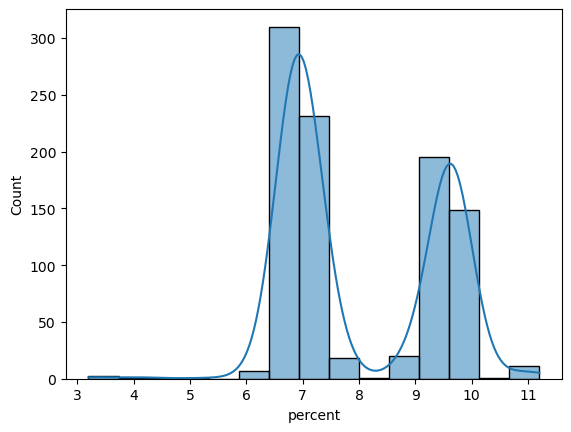

In [34]:
sns.histplot(data=dx21_ram, x="percent", kde=True)
plt.show()

In [35]:
dx21_ram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,9.480000e+02,9.480000e+02,9.480000e+02,948.000000,9.480000e+02,9.480000e+02,9.480000e+02,9.480000e+02,9.480000e+02
mean,1.700264e+10,1.564315e+10,1.359498e+09,7.994831,1.489641e+10,1.401040e+09,3.429885e+08,3.870051e+07,8.260049e+08
std,0.000000e+00,2.330065e+08,2.330065e+08,1.367338,2.356923e+08,2.462381e+08,1.090829e+07,2.261721e+05,1.121959e+07
min,1.700264e+10,1.509900e+10,5.459640e+08,3.200000,1.435163e+10,7.206666e+08,1.845821e+08,3.850240e+07,6.619136e+08
25%,1.700264e+10,1.537224e+10,1.167315e+09,6.900000,1.462482e+10,1.201111e+09,3.436216e+08,3.853517e+07,8.267694e+08
50%,1.700264e+10,1.578042e+10,1.222222e+09,7.200000,1.503272e+10,1.202946e+09,3.436216e+08,3.853517e+07,8.267694e+08
75%,1.700264e+10,1.583533e+10,1.630401e+09,9.600000,1.508764e+10,1.700053e+09,3.440968e+08,3.899392e+07,8.269824e+08
max,1.700264e+10,1.645668e+10,1.903641e+09,11.200000,1.587405e+10,1.932345e+09,3.441132e+08,3.901030e+07,8.270971e+08


### Power

In [36]:
dx21_power = pd.read_csv(f'{x21_folder_path}/power.csv')
dx21_power['timestamp'] = dx21_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx21_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-17T17:05:39.967578,0.0,5.1089,0.55677,2.8395,2026-04-17 17:05:39.967578
1,2026-04-17T17:05:40.936425,1.0,5.1059,0.74729,3.8111,2026-04-17 17:05:40.936425
2,2026-04-17T17:05:41.953576,2.0,5.1088,0.77907,3.9732,2026-04-17 17:05:41.953576
3,2026-04-17T17:05:42.967824,3.0,5.1089,0.81200,4.1412,2026-04-17 17:05:42.967824
4,2026-04-17T17:05:43.939891,4.0,5.1089,0.79770,4.0682,2026-04-17 17:05:43.939891


In [37]:
dx21_power = dx21_power.sort_values('timestamp')

# Time difference in hours
dx21_power['dt_hours'] = dx21_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx21_power['energy_Wh'] = dx21_power['Power[W]'] * dx21_power['dt_hours']

# Total energy
total_energy_Wh = dx21_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.3589765710449444
Total energy (kWh): 0.0013589765710449444


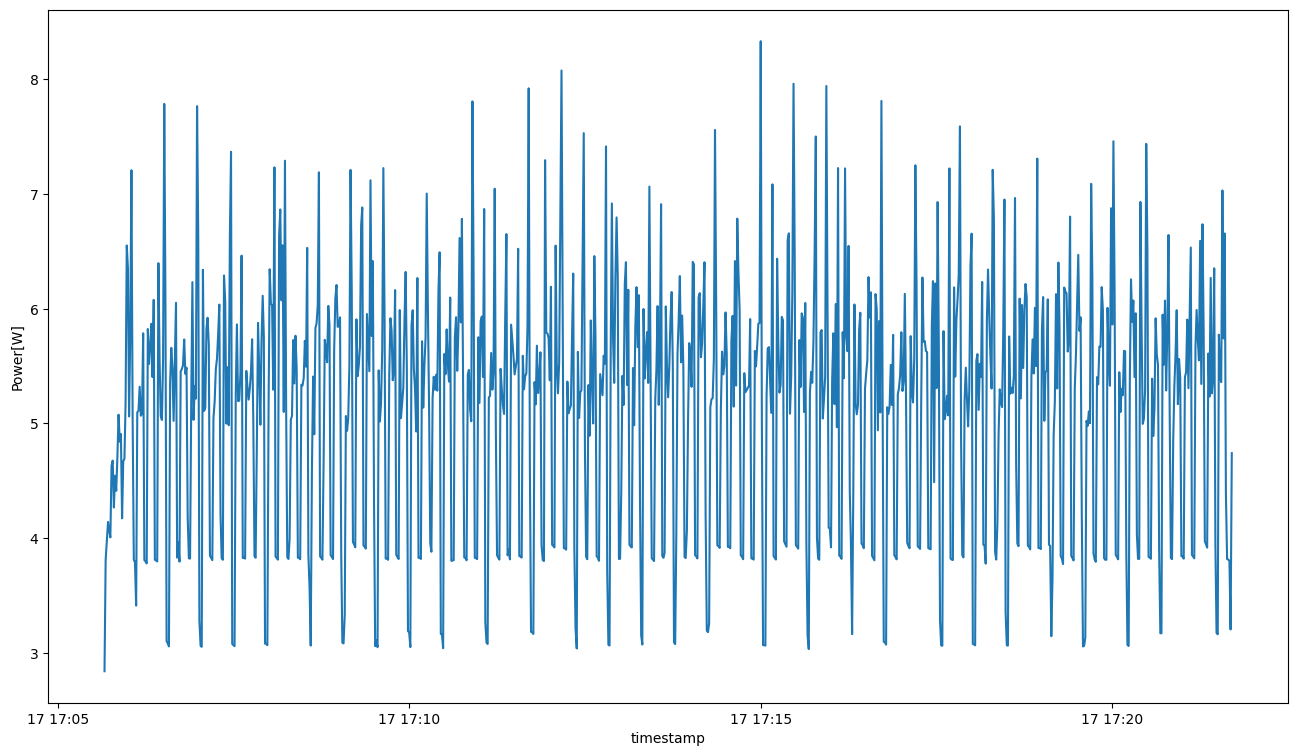

In [38]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=dx21_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

In [39]:
dx21_power.describe()

,Time[S],Volt[V],Current[A],Power[W],dt_hours,energy_Wh
count,963.000000,963.000000,963.000000,963.000000,962.000000,962.000000
mean,481.051506,5.108512,0.996084,5.082774,0.000278,0.001413
std,278.181740,0.004876,0.215800,1.101655,0.000006,0.000307
min,0.000000,5.081600,0.556770,2.839500,0.000269,0.000823
25%,240.500000,5.106800,0.767330,3.914350,0.000271,0.001090
50%,481.100000,5.108900,1.039610,5.308100,0.000283,0.001471
75%,721.600000,5.110500,1.139720,5.822300,0.000283,0.001619
max,962.100000,5.126600,1.633880,8.332700,0.000285,0.002357


## X2.2

passage_time: 05; interval: 3; window: 2

In [84]:
x22_folder_path = '../infra/reports/batch_x22'

### Predict

In [85]:
from pandas import json_normalize
import json

with open(f'{x22_folder_path}/metrics.json') as f:
    x22_data = json.load(f)

load_model_duration = datetime.fromisoformat(x22_data['load_model_final']) - datetime.fromisoformat(x22_data['load_model_start'])
    
rows = []
for animal, v1 in x22_data['animals'].items():
    row = {
        'pid': x22_data['pid'],
        'load_model_start': datetime.fromisoformat(x22_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x22_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],
    }
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx22_metrics_v0 = pd.DataFrame.from_dict(rows)#[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
dx22_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,1,2026-04-17 17:23:20.817550,2026-04-17 17:23:25.051491,2026-04-17 17:23:27.149361,5,2,2026-04-17 17:23:26.053263,2026-04-17 17:23:27.149276
1,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2,2026-04-17 17:23:30.149493,2026-04-17 17:23:34.230082,2026-04-17 17:23:36.324334,5,2,2026-04-17 17:23:35.230087,2026-04-17 17:23:36.324259
2,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,3,2026-04-17 17:23:39.326018,2026-04-17 17:23:43.413946,2026-04-17 17:23:45.510090,5,2,2026-04-17 17:23:44.418656,2026-04-17 17:23:45.510020
3,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,4,2026-04-17 17:23:48.511756,2026-04-17 17:23:52.564145,2026-04-17 17:23:54.659002,5,2,2026-04-17 17:23:53.564108,2026-04-17 17:23:54.658938
4,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,5,2026-04-17 17:23:57.660964,2026-04-17 17:24:01.727721,2026-04-17 17:24:03.836864,5,2,2026-04-17 17:24:02.728530,2026-04-17 17:24:03.836799


In [86]:
dx22_metrics_v0['by_animal_lead_time'] = dx22_metrics_v0['display_time'] - dx22_metrics_v0['first_image_capture_time']
dx22_metrics_v0['by_animal_processing_delay'] = dx22_metrics_v0['weight_prediction_final'] - dx22_metrics_v0['weight_prediction_start']
dx22_metrics_v0['by_animal_latency'] = dx22_metrics_v0['display_time'] - dx22_metrics_v0['last_image_capture_time']

dx22_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,1,2026-04-17 17:23:20.817550,2026-04-17 17:23:25.051491,2026-04-17 17:23:27.149361,5,2,2026-04-17 17:23:26.053263,2026-04-17 17:23:27.149276,0 days 00:00:06.331811,0 days 00:00:01.096013,0 days 00:00:02.097870
1,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2,2026-04-17 17:23:30.149493,2026-04-17 17:23:34.230082,2026-04-17 17:23:36.324334,5,2,2026-04-17 17:23:35.230087,2026-04-17 17:23:36.324259,0 days 00:00:06.174841,0 days 00:00:01.094172,0 days 00:00:02.094252
2,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,3,2026-04-17 17:23:39.326018,2026-04-17 17:23:43.413946,2026-04-17 17:23:45.510090,5,2,2026-04-17 17:23:44.418656,2026-04-17 17:23:45.510020,0 days 00:00:06.184072,0 days 00:00:01.091364,0 days 00:00:02.096144
3,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,4,2026-04-17 17:23:48.511756,2026-04-17 17:23:52.564145,2026-04-17 17:23:54.659002,5,2,2026-04-17 17:23:53.564108,2026-04-17 17:23:54.658938,0 days 00:00:06.147246,0 days 00:00:01.094830,0 days 00:00:02.094857
4,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,5,2026-04-17 17:23:57.660964,2026-04-17 17:24:01.727721,2026-04-17 17:24:03.836864,5,2,2026-04-17 17:24:02.728530,2026-04-17 17:24:03.836799,0 days 00:00:06.175900,0 days 00:00:01.108269,0 days 00:00:02.109143


In [87]:
collect_lead_time = dx22_metrics_v0['display_time'].max() - dx22_metrics_v0['first_image_capture_time'].min()
qtt = len(dx22_metrics_v0['animal'].unique())

dx22_metrics_v0['collect_lead_time'] = collect_lead_time
dx22_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx22_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,1,2026-04-17 17:23:20.817550,2026-04-17 17:23:25.051491,2026-04-17 17:23:27.149361,5,2,2026-04-17 17:23:26.053263,2026-04-17 17:23:27.149276,0 days 00:00:06.331811,0 days 00:00:01.096013,0 days 00:00:02.097870,0 days 00:15:12.280985,394.615262
1,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2,2026-04-17 17:23:30.149493,2026-04-17 17:23:34.230082,2026-04-17 17:23:36.324334,5,2,2026-04-17 17:23:35.230087,2026-04-17 17:23:36.324259,0 days 00:00:06.174841,0 days 00:00:01.094172,0 days 00:00:02.094252,0 days 00:15:12.280985,394.615262
2,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,3,2026-04-17 17:23:39.326018,2026-04-17 17:23:43.413946,2026-04-17 17:23:45.510090,5,2,2026-04-17 17:23:44.418656,2026-04-17 17:23:45.510020,0 days 00:00:06.184072,0 days 00:00:01.091364,0 days 00:00:02.096144,0 days 00:15:12.280985,394.615262
3,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,4,2026-04-17 17:23:48.511756,2026-04-17 17:23:52.564145,2026-04-17 17:23:54.659002,5,2,2026-04-17 17:23:53.564108,2026-04-17 17:23:54.658938,0 days 00:00:06.147246,0 days 00:00:01.094830,0 days 00:00:02.094857,0 days 00:15:12.280985,394.615262
4,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,5,2026-04-17 17:23:57.660964,2026-04-17 17:24:01.727721,2026-04-17 17:24:03.836864,5,2,2026-04-17 17:24:02.728530,2026-04-17 17:24:03.836799,0 days 00:00:06.175900,0 days 00:00:01.108269,0 days 00:00:02.109143,0 days 00:15:12.280985,394.615262


In [88]:
dx22_metrics_v0.describe()

,load_model_dur,total_of_images,suitable_images,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,100,100.0,100.0,100,100,100,100,1.000000e+02
mean,0 days 00:00:07.209811,5.0,2.0,0 days 00:00:06.151042440,0 days 00:00:01.094155640,0 days 00:00:02.093599490,0 days 00:15:12.280985,3.946153e+02
std,0 days 00:00:00,0.0,0.0,0 days 00:00:00.023086494,0 days 00:00:00.006114831,0 days 00:00:00.006548842,0 days 00:00:00,7.426872e-13
min,0 days 00:00:07.209811,5.0,2.0,0 days 00:00:06.122840,0 days 00:00:01.083887,0 days 00:00:02.079102,0 days 00:15:12.280985,3.946153e+02
25%,0 days 00:00:07.209811,5.0,2.0,0 days 00:00:06.138786250,0 days 00:00:01.090165,0 days 00:00:02.088810,0 days 00:15:12.280985,3.946153e+02
50%,0 days 00:00:07.209811,5.0,2.0,0 days 00:00:06.146558,0 days 00:00:01.092441,0 days 00:00:02.092301,0 days 00:15:12.280985,3.946153e+02
75%,0 days 00:00:07.209811,5.0,2.0,0 days 00:00:06.158405500,0 days 00:00:01.098142750,0 days 00:00:02.098106,0 days 00:15:12.280985,3.946153e+02
max,0 days 00:00:07.209811,5.0,2.0,0 days 00:00:06.331811,0 days 00:00:01.114705,0 days 00:00:02.115076,0 days 00:15:12.280985,3.946153e+02


In [89]:
dx22_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:01:49.415564')

In [90]:
total_of_imgs = dx22_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx22_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 500 - Time: 0 days 00:15:12.280985 => FPS:0.5480767529096312


### CPU

In [47]:
dx22_cpu = pd.read_csv(f'{x22_folder_path}/cpu.csv')

dx22_cpu['timestamp'] = dx22_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx22_cpu['cpu_mean']  = dx22_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx22_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-17 17:23:14.609670,3.0,3.0,3.0,94.9,25.975
1,2026-04-17 17:23:15.620245,12.6,37.6,34.7,45.5,32.600
2,2026-04-17 17:23:16.646788,0.0,0.0,0.0,99.0,24.750
3,2026-04-17 17:23:17.647689,0.0,0.0,0.0,61.4,15.350
4,2026-04-17 17:23:18.648134,0.0,0.0,0.0,3.0,0.750


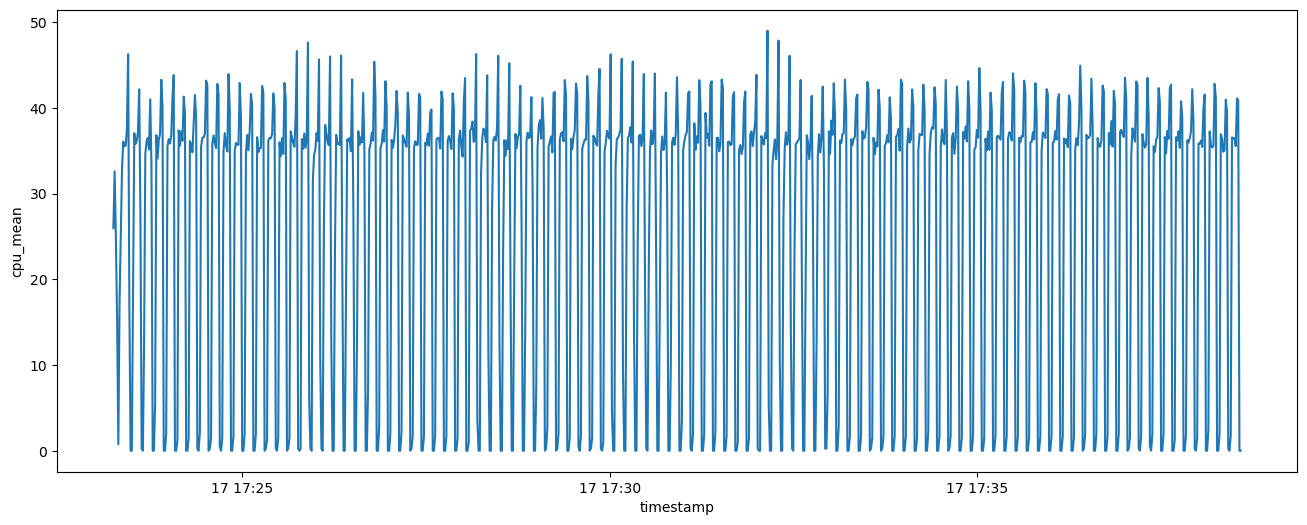

In [48]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx22_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

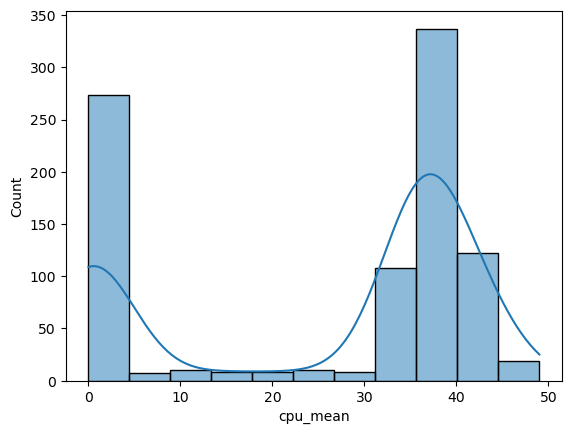

In [49]:
sns.histplot(data=dx22_cpu, x="cpu_mean", kde=True)
plt.show()

In [50]:
dx22_cpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,911.000000,911.000000,911.000000,911.000000,911.000000
mean,24.303293,27.089352,26.418441,24.326015,25.534276
std,21.778822,23.478179,22.739804,21.588562,17.307429
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,1.725000
50%,20.800000,25.500000,25.000000,21.600000,35.800000
75%,37.700000,43.600000,42.400000,38.100000,37.150000
max,91.900000,91.000000,92.100000,100.000000,49.025000


### RAM

In [51]:
dx22_ram = pd.read_csv(f'{x22_folder_path}/mem.csv')
dx22_ram['timestamp'] = dx22_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx22_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-17 17:23:13.607824,17002643456,16381460480,621182976,3.7,15799484416,719716352,184123392,38420480,661766144
1,2026-04-17 17:23:14.609496,17002643456,16340500480,662142976,3.9,15755640832,752795648,185270272,38420480,664305664
2,2026-04-17 17:23:15.625407,17002643456,16269017088,733626368,4.3,15684157440,824918016,185270272,38420480,664305664
3,2026-04-17 17:23:16.636485,17002643456,16231563264,771080192,4.5,15646572544,850165760,185270272,38420480,664436736
4,2026-04-17 17:23:17.636946,17002643456,16090972160,911671296,5.4,15468019712,982319104,223232000,38420480,702726144


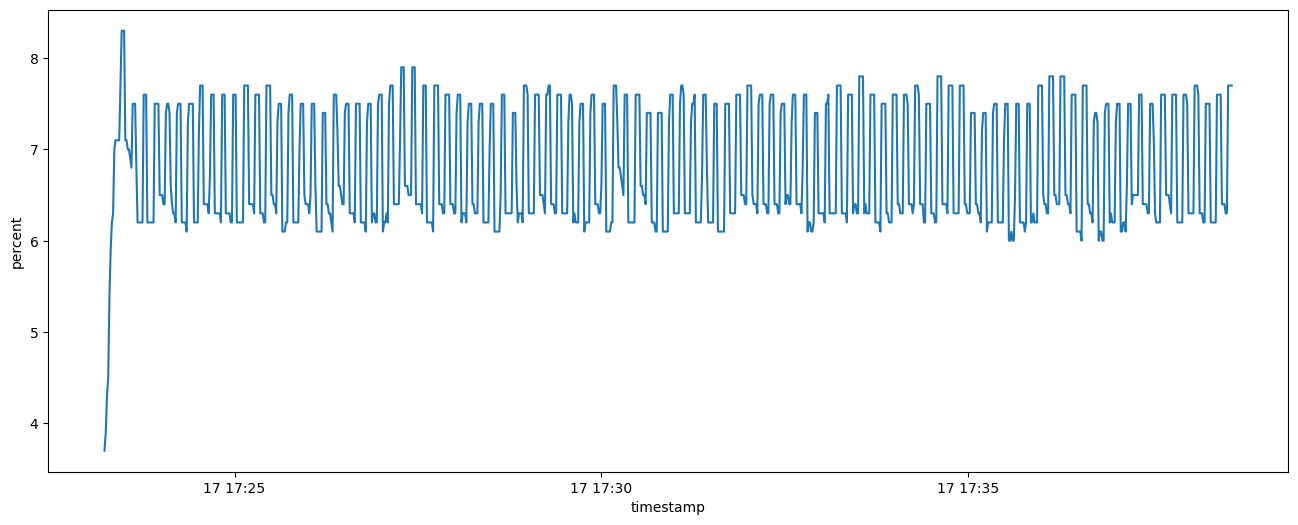

In [52]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx22_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

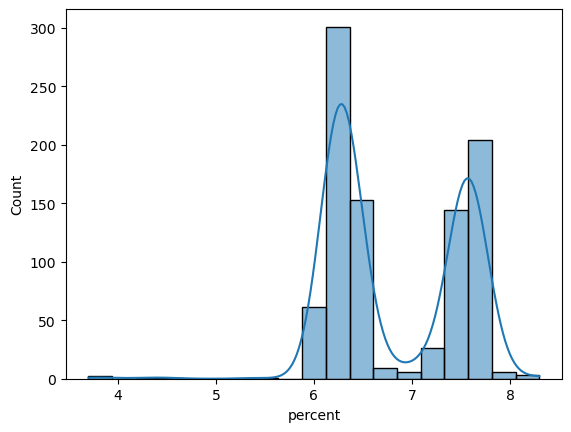

In [53]:
sns.histplot(data=dx22_ram, x="percent", kde=True)
plt.show()

In [54]:
dx22_ram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,9.180000e+02,9.180000e+02,9.180000e+02,918.000000,9.180000e+02,9.180000e+02,9.180000e+02,9.180000e+02,9.180000e+02
mean,1.700264e+10,1.584317e+10,1.159473e+09,6.817974,1.509685e+10,1.292058e+09,3.427112e+08,3.851311e+07,8.257464e+08
std,0.000000e+00,1.133172e+08,1.133172e+08,0.666567,1.171029e+08,1.184573e+08,1.121407e+07,1.284345e+05,1.153321e+07
min,1.700264e+10,1.559039e+10,6.211830e+08,3.700000,1.484328e+10,7.197164e+08,1.841234e+08,3.842048e+07,6.617661e+08
25%,1.700264e+10,1.572081e+10,1.063469e+09,6.300000,1.497362e+10,1.198686e+09,3.435233e+08,3.846963e+07,8.266220e+08
50%,1.700264e+10,1.590872e+10,1.093919e+09,6.400000,1.516129e+10,1.201848e+09,3.435233e+08,3.846963e+07,8.266220e+08
75%,1.700264e+10,1.593917e+10,1.281835e+09,7.500000,1.519201e+10,1.431421e+09,3.435397e+08,3.848602e+07,8.266220e+08
max,1.700264e+10,1.638146e+10,1.412252e+09,8.300000,1.579948e+10,1.437270e+09,3.439821e+08,3.892838e+07,8.269332e+08


### Power

In [55]:
dx22_power = pd.read_csv(f'{x22_folder_path}/power.csv')
dx22_power['timestamp'] = dx22_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx22_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-17T17:23:03.372126,0.0,5.1099,0.76189,3.8856,2026-04-17 17:23:03.372126
1,2026-04-17T17:23:04.390572,1.0,5.1045,0.86995,4.4367,2026-04-17 17:23:04.390572
2,2026-04-17T17:23:05.367513,2.0,5.1097,0.79081,4.0331,2026-04-17 17:23:05.367513
3,2026-04-17T17:23:06.387981,3.0,5.1093,0.87220,4.4482,2026-04-17 17:23:06.387981
4,2026-04-17T17:23:07.363427,4.0,5.1089,0.79309,4.0447,2026-04-17 17:23:07.363427


In [56]:
dx22_power = dx22_power.sort_values('timestamp')

# Time difference in hours
dx22_power['dt_hours'] = dx22_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx22_power['energy_Wh'] = dx22_power['Power[W]'] * dx22_power['dt_hours']

# Total energy
total_energy_Wh = dx22_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.2854588055465
Total energy (kWh): 0.0012854588055465


In [57]:
dx22_power.describe()

,Time[S],Volt[V],Current[A],Power[W],dt_hours,energy_Wh
count,936.000000,936.000000,936.000000,936.000000,935.000000,935.000000
mean,467.550962,5.109087,0.969477,4.947751,0.000278,0.001375
std,270.387535,0.004418,0.210624,1.075021,0.000006,0.000300
min,0.000000,5.091400,0.594620,3.038200,0.000269,0.000820
25%,233.750000,5.107600,0.747018,3.811875,0.000271,0.001079
50%,467.600000,5.109500,1.019705,5.205850,0.000283,0.001449
75%,701.350000,5.110800,1.116733,5.700350,0.000283,0.001583
max,935.100000,5.122800,1.504110,7.670900,0.000285,0.002176


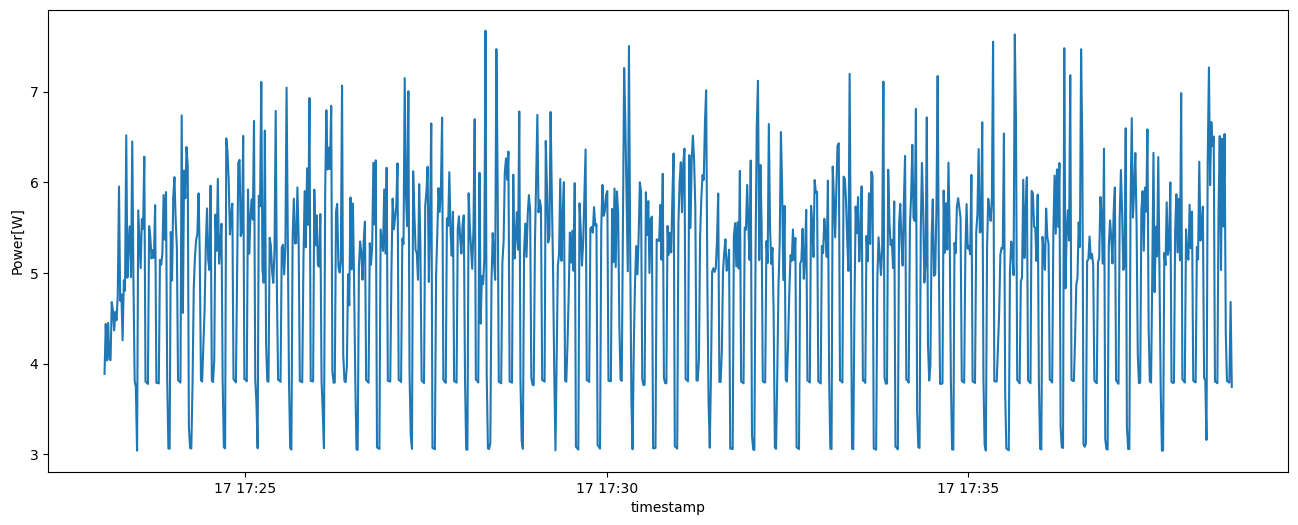

In [58]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx22_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

## X2.3

passage_time: 05; interval: 3; window: 1

In [59]:
x23_folder_path = '../infra/reports/batch_x23'

### Predict

In [60]:
from pandas import json_normalize
import json

with open(f'{x23_folder_path}/metrics.json') as f:
    x23_data = json.load(f)

load_model_duration = datetime.fromisoformat(x23_data['load_model_final']) - datetime.fromisoformat(x23_data['load_model_start'])
    
rows = []
for animal, v1 in x23_data['animals'].items():
    row = {
        'pid': x23_data['pid'],
        'load_model_start': datetime.fromisoformat(x23_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x23_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],       
    }
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx23_metrics_v0 = pd.DataFrame.from_dict(rows)#[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
dx23_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,1,2026-04-17 17:40:14.096217,2026-04-17 17:40:18.189555,2026-04-17 17:40:19.991632,5,1,2026-04-17 17:40:19.155883,2026-04-17 17:40:19.991552
1,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2,2026-04-17 17:40:22.991742,2026-04-17 17:40:27.895202,2026-04-17 17:40:29.943751,6,2,2026-04-17 17:40:28.866081,2026-04-17 17:40:29.943682
2,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,3,2026-04-17 17:40:32.944677,2026-04-17 17:40:37.880968,2026-04-17 17:40:39.704239,6,1,2026-04-17 17:40:38.869534,2026-04-17 17:40:39.704174
3,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,4,2026-04-17 17:40:42.705932,2026-04-17 17:40:47.622870,2026-04-17 17:40:49.681409,6,2,2026-04-17 17:40:48.603484,2026-04-17 17:40:49.681346
4,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,5,2026-04-17 17:40:52.683097,2026-04-17 17:40:57.636133,2026-04-17 17:40:59.681285,6,2,2026-04-17 17:40:58.604857,2026-04-17 17:40:59.681222


In [61]:
dx23_metrics_v0['by_animal_lead_time'] = dx23_metrics_v0['display_time'] - dx23_metrics_v0['first_image_capture_time']
dx23_metrics_v0['by_animal_processing_delay'] = dx23_metrics_v0['weight_prediction_final'] - dx23_metrics_v0['weight_prediction_start']
dx23_metrics_v0['by_animal_latency'] = dx23_metrics_v0['display_time'] - dx23_metrics_v0['last_image_capture_time']

dx23_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,1,2026-04-17 17:40:14.096217,2026-04-17 17:40:18.189555,2026-04-17 17:40:19.991632,5,1,2026-04-17 17:40:19.155883,2026-04-17 17:40:19.991552,0 days 00:00:05.895415,0 days 00:00:00.835669,0 days 00:00:01.802077
1,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2,2026-04-17 17:40:22.991742,2026-04-17 17:40:27.895202,2026-04-17 17:40:29.943751,6,2,2026-04-17 17:40:28.866081,2026-04-17 17:40:29.943682,0 days 00:00:06.952009,0 days 00:00:01.077601,0 days 00:00:02.048549
2,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,3,2026-04-17 17:40:32.944677,2026-04-17 17:40:37.880968,2026-04-17 17:40:39.704239,6,1,2026-04-17 17:40:38.869534,2026-04-17 17:40:39.704174,0 days 00:00:06.759562,0 days 00:00:00.834640,0 days 00:00:01.823271
3,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,4,2026-04-17 17:40:42.705932,2026-04-17 17:40:47.622870,2026-04-17 17:40:49.681409,6,2,2026-04-17 17:40:48.603484,2026-04-17 17:40:49.681346,0 days 00:00:06.975477,0 days 00:00:01.077862,0 days 00:00:02.058539
4,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,5,2026-04-17 17:40:52.683097,2026-04-17 17:40:57.636133,2026-04-17 17:40:59.681285,6,2,2026-04-17 17:40:58.604857,2026-04-17 17:40:59.681222,0 days 00:00:06.998188,0 days 00:00:01.076365,0 days 00:00:02.045152


In [62]:
collect_lead_time = dx23_metrics_v0['display_time'].max() - dx23_metrics_v0['first_image_capture_time'].min()
qtt = len(dx23_metrics_v0['animal'].unique())

dx23_metrics_v0['collect_lead_time'] = collect_lead_time
dx23_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx23_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,1,2026-04-17 17:40:14.096217,2026-04-17 17:40:18.189555,2026-04-17 17:40:19.991632,5,1,2026-04-17 17:40:19.155883,2026-04-17 17:40:19.991552,0 days 00:00:05.895415,0 days 00:00:00.835669,0 days 00:00:01.802077,0 days 00:16:28.097418,364.336546
1,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2,2026-04-17 17:40:22.991742,2026-04-17 17:40:27.895202,2026-04-17 17:40:29.943751,6,2,2026-04-17 17:40:28.866081,2026-04-17 17:40:29.943682,0 days 00:00:06.952009,0 days 00:00:01.077601,0 days 00:00:02.048549,0 days 00:16:28.097418,364.336546
2,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,3,2026-04-17 17:40:32.944677,2026-04-17 17:40:37.880968,2026-04-17 17:40:39.704239,6,1,2026-04-17 17:40:38.869534,2026-04-17 17:40:39.704174,0 days 00:00:06.759562,0 days 00:00:00.834640,0 days 00:00:01.823271,0 days 00:16:28.097418,364.336546
3,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,4,2026-04-17 17:40:42.705932,2026-04-17 17:40:47.622870,2026-04-17 17:40:49.681409,6,2,2026-04-17 17:40:48.603484,2026-04-17 17:40:49.681346,0 days 00:00:06.975477,0 days 00:00:01.077862,0 days 00:00:02.058539,0 days 00:16:28.097418,364.336546
4,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,5,2026-04-17 17:40:52.683097,2026-04-17 17:40:57.636133,2026-04-17 17:40:59.681285,6,2,2026-04-17 17:40:58.604857,2026-04-17 17:40:59.681222,0 days 00:00:06.998188,0 days 00:00:01.076365,0 days 00:00:02.045152,0 days 00:16:28.097418,364.336546


In [63]:
dx23_metrics_v0.describe()

,load_model_dur,total_of_images,suitable_images,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,100,100.00,100.000000,100,100,100,100,1.000000e+02
mean,0 days 00:00:06.967363,5.99,1.760000,0 days 00:00:06.909305790,0 days 00:00:01.019039250,0 days 00:00:01.995511930,0 days 00:16:28.097418,3.643365e+02
std,0 days 00:00:00,0.10,0.429235,0 days 00:00:00.139444473,0 days 00:00:00.104033509,0 days 00:00:00.100743214,0 days 00:00:00,5.712979e-14
min,0 days 00:00:06.967363,5.00,1.000000,0 days 00:00:05.895415,0 days 00:00:00.831709,0 days 00:00:01.802077,0 days 00:16:28.097418,3.643365e+02
25%,0 days 00:00:06.967363,6.00,2.000000,0 days 00:00:06.940671750,0 days 00:00:01.065616,0 days 00:00:02.036826750,0 days 00:16:28.097418,3.643365e+02
50%,0 days 00:00:06.967363,6.00,2.000000,0 days 00:00:06.960227500,0 days 00:00:01.072188500,0 days 00:00:02.047566500,0 days 00:16:28.097418,3.643365e+02
75%,0 days 00:00:06.967363,6.00,2.000000,0 days 00:00:06.976052750,0 days 00:00:01.081017250,0 days 00:00:02.053530,0 days 00:16:28.097418,3.643365e+02
max,0 days 00:00:06.967363,6.00,2.000000,0 days 00:00:07.013703,0 days 00:00:01.097816,0 days 00:00:02.088859,0 days 00:16:28.097418,3.643365e+02


In [64]:
dx23_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:01:41.903925')

In [65]:
total_of_imgs = dx23_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx23_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 599 - Time: 0 days 00:16:28.097418 => FPS:0.606215530056167


### CPU

In [66]:
dx23_cpu = pd.read_csv(f'{x23_folder_path}/cpu.csv')

dx23_cpu['timestamp'] = dx23_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx23_cpu['cpu_mean']  = dx23_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx23_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-17 17:40:08.129732,1.0,3.0,95.0,2.0,25.250
1,2026-04-17 17:40:09.145478,11.0,40.8,63.0,10.0,31.200
2,2026-04-17 17:40:10.319013,0.9,81.2,17.5,0.9,25.125
3,2026-04-17 17:40:11.319525,1.0,0.0,37.6,0.0,9.650
4,2026-04-17 17:40:12.319928,0.0,0.0,4.0,1.0,1.250


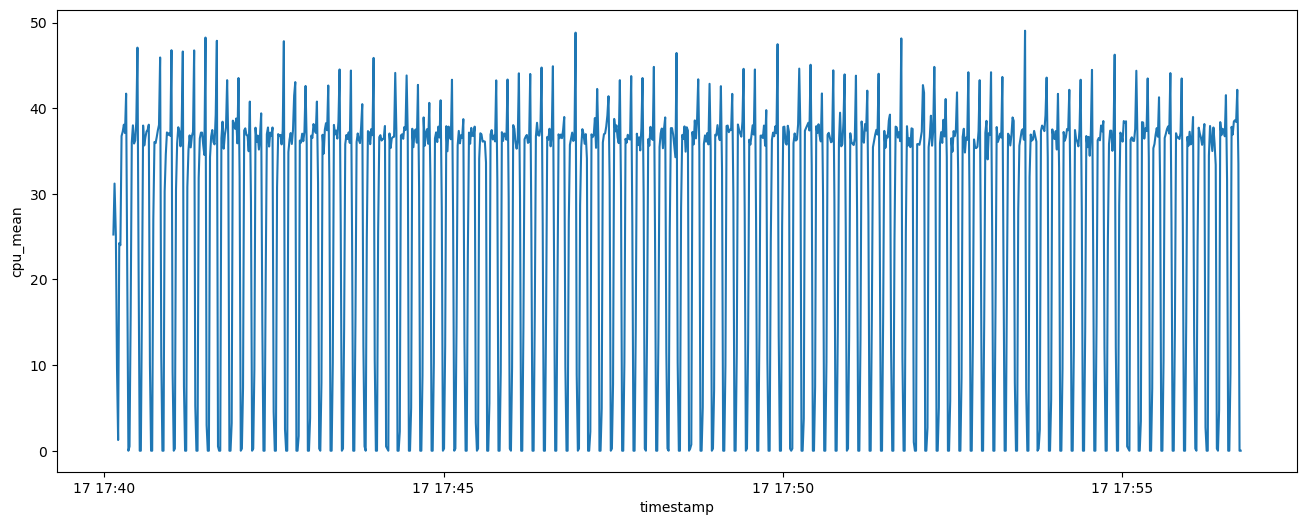

In [67]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx23_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

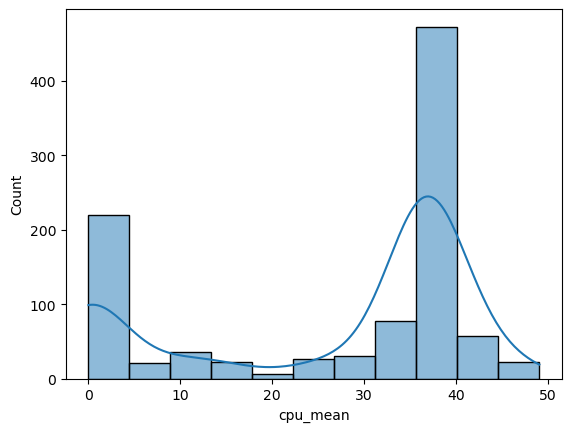

In [68]:
sns.histplot(data=dx23_cpu, x="cpu_mean", kde=True)
plt.show()

In [69]:
dx23_cpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,994.000000,994.000000,994.000000,994.000000,994.000000
mean,23.690040,28.871932,29.372535,24.061066,26.498893
std,19.355075,23.076808,24.281167,19.351144,16.035689
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.100000,6.100000,6.000000,6.025000,9.743750
50%,20.900000,26.250000,24.600000,22.000000,36.087500
75%,34.700000,44.600000,45.875000,35.375000,37.300000
max,90.000000,91.900000,97.000000,88.000000,49.050000


### RAM

In [70]:
dx23_ram = pd.read_csv(f'{x23_folder_path}/mem.csv')
dx23_ram['timestamp'] = dx23_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx23_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-17 17:40:07.128923,17002643456,16404578304,598065152,3.5,15822569472,720044032,184516608,38420480,661749760
1,2026-04-17 17:40:08.129821,17002643456,16333815808,668827648,3.9,15748857856,756531200,185319424,38436864,664272896
2,2026-04-17 17:40:09.145592,17002643456,16282173440,720470016,4.2,15697215488,824082432,185319424,38436864,664272896
3,2026-04-17 17:40:10.166128,17002643456,16220372992,782270464,4.6,15635283968,862765056,185319424,38436864,664403968
4,2026-04-17 17:40:11.166486,17002643456,16079405056,923238400,5.4,15447244800,991363072,232390656,38436864,711868416


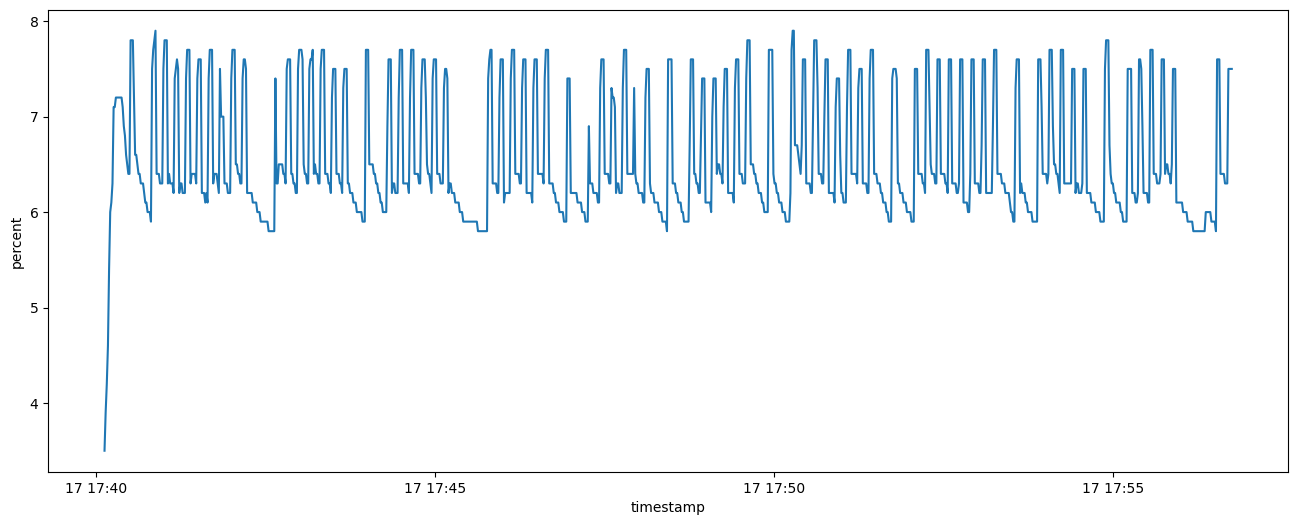

In [71]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx23_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

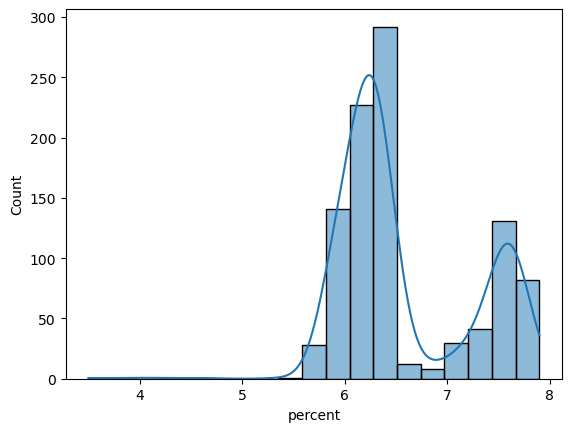

In [72]:
sns.histplot(data=dx23_ram, x="percent", kde=True)
plt.show()

In [73]:
dx23_ram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,9.970000e+02,9.970000e+02,9.970000e+02,997.00000,9.970000e+02,9.970000e+02,9.970000e+02,9.970000e+02,9.970000e+02
mean,1.700264e+10,1.588490e+10,1.117741e+09,6.57342,1.513834e+10,1.261533e+09,3.428880e+08,3.856470e+07,8.258285e+08
std,0.000000e+00,1.109866e+08,1.109866e+08,0.65443,1.141987e+08,1.039854e+08,1.063222e+07,1.534324e+05,1.093728e+07
min,1.700264e+10,1.565575e+10,5.980652e+08,3.50000,1.490849e+10,7.200440e+08,1.845166e+08,3.842048e+07,6.617498e+08
25%,1.700264e+10,1.576393e+10,1.043513e+09,6.10000,1.501664e+10,1.202749e+09,3.435889e+08,3.850240e+07,8.266056e+08
50%,1.700264e+10,1.592964e+10,1.073005e+09,6.30000,1.518233e+10,1.203716e+09,3.436052e+08,3.851878e+07,8.266056e+08
75%,1.700264e+10,1.595913e+10,1.238712e+09,7.30000,1.521182e+10,1.388642e+09,3.436052e+08,3.851878e+07,8.266056e+08
max,1.700264e+10,1.640458e+10,1.346896e+09,7.90000,1.582257e+10,1.437745e+09,3.440476e+08,3.896115e+07,8.268841e+08


### Power

In [74]:
dx23_power = pd.read_csv(f'{x23_folder_path}/power.csv')
dx23_power['timestamp'] = dx23_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx23_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-17T17:39:56.343834,0.0,5.1097,0.71063,3.6242,2026-04-17 17:39:56.343834
1,2026-04-17T17:39:57.315169,1.0,5.1097,0.71011,3.6215,2026-04-17 17:39:57.315169
2,2026-04-17T17:39:58.331580,2.0,5.1100,0.82029,4.1916,2026-04-17 17:39:58.331580
3,2026-04-17T17:39:59.347140,3.0,5.1098,0.79178,4.0380,2026-04-17 17:39:59.347140
4,2026-04-17T17:40:00.317420,4.0,5.1098,0.86316,4.4021,2026-04-17 17:40:00.317420


In [75]:
dx23_power = dx23_power.sort_values('timestamp')

# Time difference in hours
dx23_power['dt_hours'] = dx23_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx23_power['energy_Wh'] = dx23_power['Power[W]'] * dx23_power['dt_hours']

# Total energy
total_energy_Wh = dx23_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.4217573599010276
Total energy (kWh): 0.0014217573599010277


In [76]:
dx23_power.describe()

,Time[S],Volt[V],Current[A],Power[W],dt_hours,energy_Wh
count,1015.000000,1015.000000,1015.000000,1015.000000,1014.000000,1014.000000
mean,507.057537,5.109641,0.988373,5.045314,0.000278,0.001402
std,293.191903,0.004281,0.188822,0.963742,0.000006,0.000270
min,0.000000,5.092200,0.599710,3.064500,0.000269,0.000827
25%,253.500000,5.108450,0.752070,3.841350,0.000271,0.001085
50%,507.100000,5.110000,1.024830,5.231200,0.000283,0.001461
75%,760.600000,5.111300,1.125370,5.748000,0.000283,0.001586
max,1014.100000,5.126100,1.635720,8.342100,0.000285,0.002261


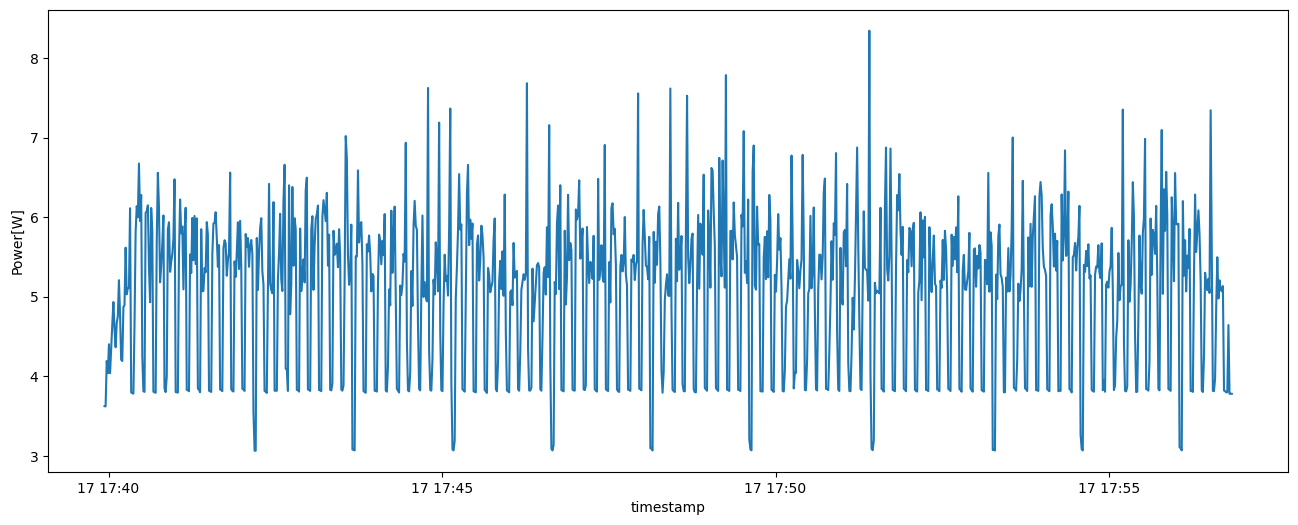

In [77]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx23_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

## X3.1 ~ Mas (Batch) | Baseline

passage_time: 10; interval: 3; window: 1; FPS: 1.0

In [111]:
x31_folder_path = '../infra/reports/mas-batch_baseline'

### Predict

In [4]:
from pandas import json_normalize
import json

with open(f'{x31_folder_path}/metrics.json') as f:
    x31_data = json.load(f)

load_model_duration = datetime.fromisoformat(x31_data['load_model_final']) - datetime.fromisoformat(x31_data['load_model_start'])
    
rows = []
for animal, v1 in x31_data['animals'].items():
    row = {
        'pid': x31_data['pid'],
        'load_model_start': datetime.fromisoformat(x31_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x31_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],       
    }
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx31_metrics_v0 = pd.DataFrame.from_dict(rows)#[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
dx31_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,mas-batch_2026-04-26T15:50:05.931416,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,1,2026-04-26 15:50:18.548265,2026-04-26 15:50:27.558000,2026-04-26 15:50:29.851377,10,3,2026-04-26 15:50:28.564839,2026-04-26 15:50:29.851267
1,mas-batch_2026-04-26T15:50:05.931416,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,2,2026-04-26 15:50:32.564167,2026-04-26 15:50:40.569086,2026-04-26 15:50:42.655793,9,2,2026-04-26 15:50:41.575030,2026-04-26 15:50:42.655675
2,mas-batch_2026-04-26T15:50:05.931416,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,3,2026-04-26 15:50:45.573505,2026-04-26 15:50:53.580690,2026-04-26 15:50:55.653652,9,2,2026-04-26 15:50:54.587075,2026-04-26 15:50:55.653559
3,mas-batch_2026-04-26T15:50:05.931416,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,4,2026-04-26 15:50:58.586126,2026-04-26 15:51:06.593670,2026-04-26 15:51:08.667715,9,2,2026-04-26 15:51:07.605299,2026-04-26 15:51:08.667624
4,mas-batch_2026-04-26T15:50:05.931416,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,5,2026-04-26 15:51:11.599436,2026-04-26 15:51:19.607232,2026-04-26 15:51:21.691642,9,2,2026-04-26 15:51:20.613699,2026-04-26 15:51:21.691548


In [5]:
dx31_metrics_v0['by_animal_lead_time'] = dx31_metrics_v0['display_time'] - dx31_metrics_v0['first_image_capture_time']
dx31_metrics_v0['by_animal_processing_delay'] = dx31_metrics_v0['weight_prediction_final'] - dx31_metrics_v0['weight_prediction_start']
dx31_metrics_v0['by_animal_latency'] = dx31_metrics_v0['display_time'] - dx31_metrics_v0['last_image_capture_time']

dx31_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,mas-batch_2026-04-26T15:50:05.931416,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,1,2026-04-26 15:50:18.548265,2026-04-26 15:50:27.558000,2026-04-26 15:50:29.851377,10,3,2026-04-26 15:50:28.564839,2026-04-26 15:50:29.851267,0 days 00:00:11.303112,0 days 00:00:01.286428,0 days 00:00:02.293377
1,mas-batch_2026-04-26T15:50:05.931416,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,2,2026-04-26 15:50:32.564167,2026-04-26 15:50:40.569086,2026-04-26 15:50:42.655793,9,2,2026-04-26 15:50:41.575030,2026-04-26 15:50:42.655675,0 days 00:00:10.091626,0 days 00:00:01.080645,0 days 00:00:02.086707
2,mas-batch_2026-04-26T15:50:05.931416,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,3,2026-04-26 15:50:45.573505,2026-04-26 15:50:53.580690,2026-04-26 15:50:55.653652,9,2,2026-04-26 15:50:54.587075,2026-04-26 15:50:55.653559,0 days 00:00:10.080147,0 days 00:00:01.066484,0 days 00:00:02.072962
3,mas-batch_2026-04-26T15:50:05.931416,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,4,2026-04-26 15:50:58.586126,2026-04-26 15:51:06.593670,2026-04-26 15:51:08.667715,9,2,2026-04-26 15:51:07.605299,2026-04-26 15:51:08.667624,0 days 00:00:10.081589,0 days 00:00:01.062325,0 days 00:00:02.074045
4,mas-batch_2026-04-26T15:50:05.931416,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,5,2026-04-26 15:51:11.599436,2026-04-26 15:51:19.607232,2026-04-26 15:51:21.691642,9,2,2026-04-26 15:51:20.613699,2026-04-26 15:51:21.691548,0 days 00:00:10.092206,0 days 00:00:01.077849,0 days 00:00:02.084410


In [6]:
collect_lead_time = dx31_metrics_v0['display_time'].max() - dx31_metrics_v0['first_image_capture_time'].min()
qtt = len(dx31_metrics_v0['animal'].unique())

dx31_metrics_v0['collect_lead_time'] = collect_lead_time
dx31_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx31_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,mas-batch_2026-04-26T15:50:05.931416,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,1,2026-04-26 15:50:18.548265,2026-04-26 15:50:27.558000,2026-04-26 15:50:29.851377,10,3,2026-04-26 15:50:28.564839,2026-04-26 15:50:29.851267,0 days 00:00:11.303112,0 days 00:00:01.286428,0 days 00:00:02.293377,0 days 00:21:39.642202,276.999315
1,mas-batch_2026-04-26T15:50:05.931416,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,2,2026-04-26 15:50:32.564167,2026-04-26 15:50:40.569086,2026-04-26 15:50:42.655793,9,2,2026-04-26 15:50:41.575030,2026-04-26 15:50:42.655675,0 days 00:00:10.091626,0 days 00:00:01.080645,0 days 00:00:02.086707,0 days 00:21:39.642202,276.999315
2,mas-batch_2026-04-26T15:50:05.931416,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,3,2026-04-26 15:50:45.573505,2026-04-26 15:50:53.580690,2026-04-26 15:50:55.653652,9,2,2026-04-26 15:50:54.587075,2026-04-26 15:50:55.653559,0 days 00:00:10.080147,0 days 00:00:01.066484,0 days 00:00:02.072962,0 days 00:21:39.642202,276.999315
3,mas-batch_2026-04-26T15:50:05.931416,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,4,2026-04-26 15:50:58.586126,2026-04-26 15:51:06.593670,2026-04-26 15:51:08.667715,9,2,2026-04-26 15:51:07.605299,2026-04-26 15:51:08.667624,0 days 00:00:10.081589,0 days 00:00:01.062325,0 days 00:00:02.074045,0 days 00:21:39.642202,276.999315
4,mas-batch_2026-04-26T15:50:05.931416,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,5,2026-04-26 15:51:11.599436,2026-04-26 15:51:19.607232,2026-04-26 15:51:21.691642,9,2,2026-04-26 15:51:20.613699,2026-04-26 15:51:21.691548,0 days 00:00:10.092206,0 days 00:00:01.077849,0 days 00:00:02.084410,0 days 00:21:39.642202,276.999315


In [7]:
dx31_metrics_v0.describe()

,load_model_start,load_model_final,load_model_dur,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,100,100,100,100,100,100,100.00,100.00,100,100,100,100,100,100,1.000000e+02
mean,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,2026-04-26 16:01:03.801126,2026-04-26 16:01:11.818353,2026-04-26 16:01:13.898557,9.01,2.01,2026-04-26 16:01:12.826675,2026-04-26 16:01:13.898462,0 days 00:00:10.097430,0 days 00:00:01.071787,0 days 00:00:02.080205,0 days 00:21:39.642202,2.769993e+02
min,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,2026-04-26 15:50:18.548265,2026-04-26 15:50:27.558000,2026-04-26 15:50:29.851377,9.00,2.00,2026-04-26 15:50:28.564839,2026-04-26 15:50:29.851267,0 days 00:00:10.056670,0 days 00:00:01.043432,0 days 00:00:02.050586,0 days 00:21:39.642202,2.769993e+02
25%,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,2026-04-26 15:55:41.616954,2026-04-26 15:55:49.625907,2026-04-26 15:55:51.688286,9.00,2.00,2026-04-26 15:55:50.633074,2026-04-26 15:55:51.688196,0 days 00:00:10.070249,0 days 00:00:01.055867,0 days 00:00:02.064201,0 days 00:21:39.642202,2.769993e+02
50%,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,2026-04-26 16:01:03.680565,2026-04-26 16:01:11.688736,2026-04-26 16:01:13.743316,9.00,2.00,2026-04-26 16:01:12.698292,2026-04-26 16:01:13.743224,0 days 00:00:10.080443,0 days 00:00:01.065225,0 days 00:00:02.073578,0 days 00:21:39.642202,2.769993e+02
75%,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,2026-04-26 16:06:26.015255,2026-04-26 16:06:34.021682,2026-04-26 16:06:36.089710,9.00,2.00,2026-04-26 16:06:35.029782,2026-04-26 16:06:36.089617,0 days 00:00:10.092750,0 days 00:00:01.078039,0 days 00:00:02.086877,0 days 00:21:39.642202,2.769993e+02
max,2026-04-26 15:50:07.538678,2026-04-26 15:50:18.494771,0 days 00:00:10.956093,2026-04-26 16:11:48.098054,2026-04-26 16:11:56.103464,2026-04-26 16:11:58.190467,10.00,3.00,2026-04-26 16:11:57.112384,2026-04-26 16:11:58.190375,0 days 00:00:11.303112,0 days 00:00:01.321586,0 days 00:00:02.328842,0 days 00:21:39.642202,2.769993e+02
std,NaN,NaN,0 days 00:00:00,NaN,NaN,NaN,0.10,0.10,NaN,NaN,0 days 00:00:00.125455,0 days 00:00:00.036836,0 days 00:00:00.036769,0 days 00:00:00,1.142596e-13


In [8]:
dx31_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:01:47.178723')

In [9]:
total_of_imgs = dx31_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx31_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 901 - Time: 0 days 00:21:39.642202 => FPS:0.6932677306211391


### CPU

In [151]:
dx31_cpu = pd.read_csv(f'{x31_folder_path}/cpu.csv')

dx31_cpu['arch-str']  = 'agt-single'
dx31_cpu['timestamp'] = dx31_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx31_cpu['cpu_mean']  = dx31_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx31_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,arch-str,cpu_mean
0,2026-04-26 15:50:08.539180,13.1,37.0,22.2,56.4,agt-single,32.175
1,2026-04-26 15:50:09.539627,34.3,30.6,34.3,38.6,agt-single,34.450
2,2026-04-26 15:50:10.542701,41.0,51.5,37.1,37.4,agt-single,41.750
3,2026-04-26 15:50:11.543533,59.0,4.0,59.6,2.0,agt-single,31.150
4,2026-04-26 15:50:12.544240,71.6,1.0,71.2,0.0,agt-single,35.950


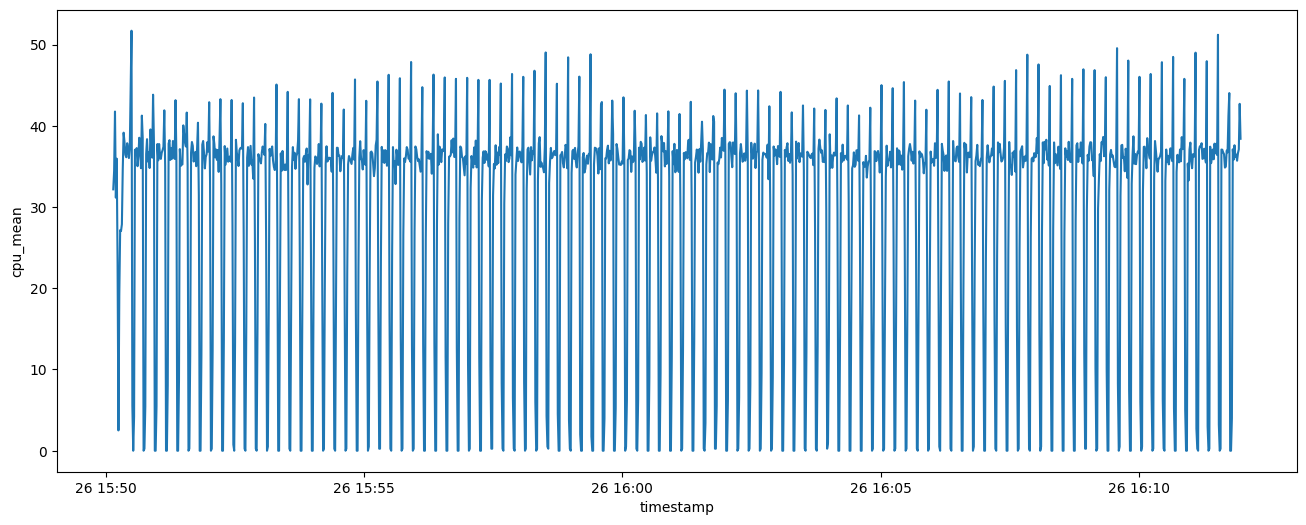

In [113]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx31_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

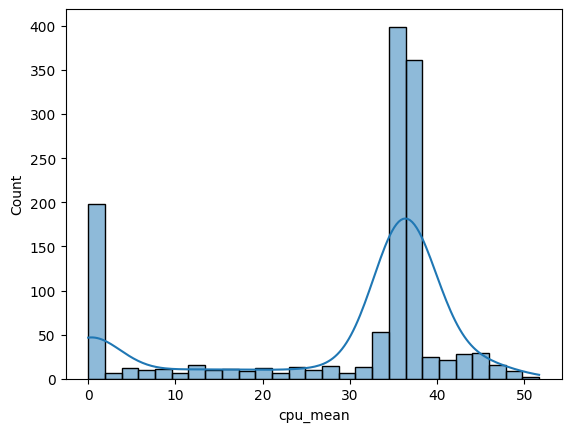

In [114]:
sns.histplot(data=dx31_cpu, x="cpu_mean", kde=True)
plt.show()

In [115]:
dx31_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1307,1307.000000,1307.000000,1307.000000,1307.000000,1307.00000
mean,2026-04-26 16:01:03.445924,28.067865,30.492655,31.370543,26.426855,29.08948
min,2026-04-26 15:50:08.539180,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2026-04-26 15:55:36.029039,18.150000,18.400000,19.200000,17.300000,26.33750
50%,2026-04-26 16:01:03.497648,27.100000,32.300000,32.700000,26.300000,35.87500
75%,2026-04-26 16:06:30.844514,40.100000,43.950000,44.950000,38.000000,37.02500
max,2026-04-26 16:11:58.296989,85.900000,83.300000,85.000000,84.200000,51.70000
std,NaN,18.606225,19.504792,20.038818,16.891733,14.40545


In [116]:
threshold = dx31_cpu['cpu_mean'].quantile(0.75)
dx31_cpu[dx31_cpu['cpu_mean'] > threshold].describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,325,325.000000,325.000000,325.000000,325.000000,325.000000
mean,2026-04-26 16:00:55.761171,38.557538,41.832615,42.497231,36.578154,39.866385
min,2026-04-26 15:50:10.542701,18.600000,19.000000,19.800000,18.000000,37.025000
25%,2026-04-26 15:55:14.476474,26.500000,32.300000,31.700000,26.500000,37.375000
50%,2026-04-26 16:00:48.458070,36.600000,39.800000,41.200000,35.000000,37.950000
75%,2026-04-26 16:07:04.431767,46.000000,50.900000,51.000000,45.000000,42.500000
max,2026-04-26 16:11:58.296989,85.900000,82.700000,83.500000,74.000000,51.700000
std,NaN,14.404288,13.350172,14.236985,11.867566,3.513963


### RAM

In [117]:
dx31_ram = pd.read_csv(f'{x31_folder_path}/mem.csv')
dx31_ram['timestamp'] = dx31_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx31_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-26 15:50:07.536612,17002643456,16311533568,691109888,4.1,15699148800,771375104,208928768,42500096,688865280
1,2026-04-26 15:50:08.538370,17002643456,16281845760,720797696,4.2,15666888704,800784384,209813504,42598400,691388416
2,2026-04-26 15:50:09.538759,17002643456,16243015680,759627776,4.5,15628058624,840908800,209813504,42598400,691388416
3,2026-04-26 15:50:10.539341,17002643456,16144711680,857931776,5.0,15529754624,948797440,209813504,42598400,691388416
4,2026-04-26 15:50:11.541005,17002643456,16139436032,863207424,5.1,15524347904,940867584,209813504,42598400,691519488


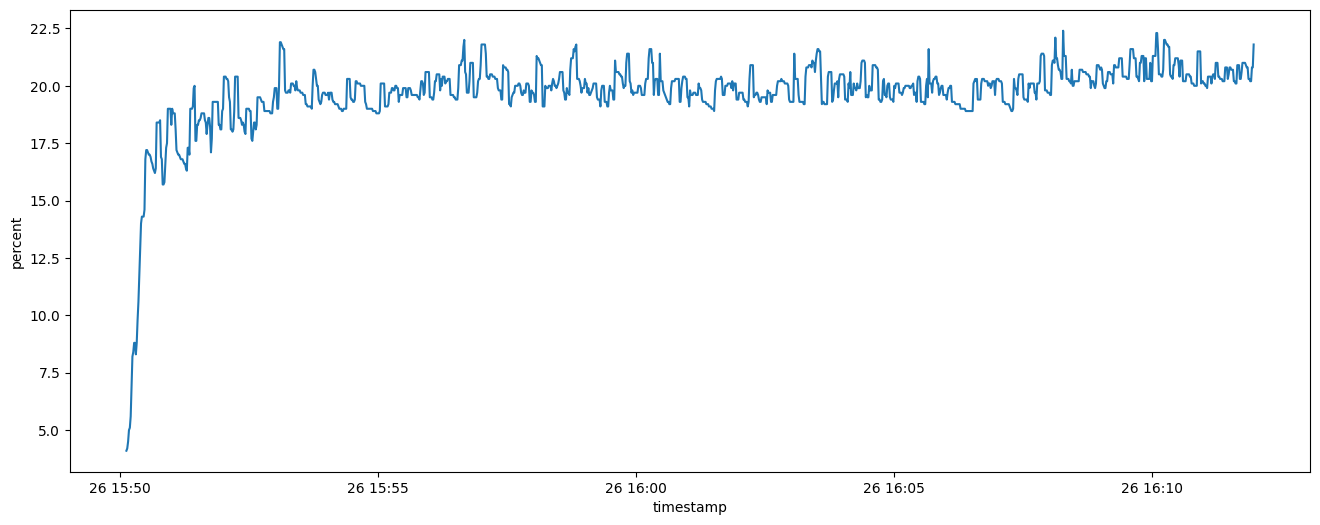

In [118]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx31_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

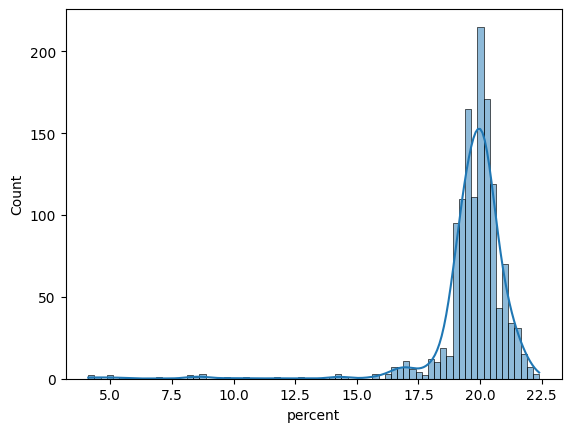

In [119]:
sns.histplot(data=dx31_ram, x="percent", kde=True)
plt.show()

In [120]:
dx31_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,1309,1.309000e+03,1.309000e+03,1.309000e+03,1309.000000,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03
mean,2026-04-26 16:01:03.040622,1.700264e+10,1.365433e+10,3.348316e+09,19.691979,1.287779e+10,3.498295e+09,3.673345e+08,4.276125e+07,8.529168e+08
min,2026-04-26 15:50:07.536612,1.700264e+10,1.318874e+10,6.911099e+08,4.100000,1.241106e+10,7.713751e+08,2.089288e+08,4.250010e+07,6.888653e+08
25%,2026-04-26 15:55:35.343896,1.700264e+10,1.354385e+10,3.291251e+09,19.400000,1.276656e+10,3.457663e+09,3.680502e+08,4.263117e+07,8.537539e+08
50%,2026-04-26 16:01:03.027754,1.700264e+10,1.361201e+10,3.390636e+09,19.900000,1.283449e+10,3.542893e+09,3.680666e+08,4.264755e+07,8.537702e+08
75%,2026-04-26 16:06:30.677827,1.700264e+10,1.371139e+10,3.458793e+09,20.300000,1.293410e+10,3.612951e+09,3.683942e+08,4.297523e+07,8.538849e+08
max,2026-04-26 16:11:58.510073,1.700264e+10,1.631153e+10,3.813900e+09,22.400000,1.569915e+10,3.927654e+09,3.684106e+08,4.299162e+07,8.539505e+08
std,NaN,0.000000e+00,2.910122e+08,2.910122e+08,1.711225,2.987108e+08,3.094106e+08,1.126750e+07,1.647445e+05,1.157997e+07


In [121]:
threshold = dx31_ram['percent'].quantile(0.75)
dx31_ram[dx31_ram['percent'] > threshold].describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,322,3.220000e+02,3.220000e+02,3.220000e+02,322.000000,3.220000e+02,3.220000e+02,3.220000e+02,3.220000e+02,3.220000e+02
mean,2026-04-26 16:04:44.966430,1.700264e+10,1.344702e+10,3.555625e+09,20.914286,1.266950e+10,3.697659e+09,3.682558e+08,4.283688e+07,8.538303e+08
min,2026-04-26 15:52:00.927253,1.700264e+10,1.318874e+10,3.460301e+09,20.400000,1.241106e+10,3.477488e+09,3.680338e+08,4.261478e+07,8.537375e+08
25%,2026-04-26 15:58:50.006693,1.700264e+10,1.339733e+10,3.488674e+09,20.500000,1.261964e+10,3.657482e+09,3.680666e+08,4.264755e+07,8.537539e+08
50%,2026-04-26 16:07:28.291199,1.700264e+10,1.345893e+10,3.543712e+09,20.800000,1.268144e+10,3.684024e+09,3.683942e+08,4.297523e+07,8.538849e+08
75%,2026-04-26 16:09:52.993224,1.700264e+10,1.351397e+10,3.605316e+09,21.200000,1.273638e+10,3.749872e+09,3.683942e+08,4.297523e+07,8.538849e+08
max,2026-04-26 16:11:58.510073,1.700264e+10,1.354234e+10,3.813900e+09,22.400000,1.276464e+10,3.927654e+09,3.684106e+08,4.299162e+07,8.539505e+08
std,NaN,0.000000e+00,7.629206e+07,7.629206e+07,0.448515,7.628947e+07,7.918279e+07,1.666778e+05,1.667227e+05,6.318054e+04


### Power

In [217]:
dx31_power = pd.read_csv(f'{x31_folder_path}/power.csv')
dx31_power['timestamp'] = dx31_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx31_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-26T15:49:55.582299,0.0,5.1085,0.56780,2.8957,2026-04-26 15:49:55.582299
1,2026-04-26T15:49:56.550881,1.0,5.1084,0.83057,4.2359,2026-04-26 15:49:56.550881
2,2026-04-26T15:49:57.571601,2.0,5.1056,0.78752,4.0163,2026-04-26 15:49:57.571601
3,2026-04-26T15:49:58.591816,3.0,5.1080,0.94402,4.8145,2026-04-26 15:49:58.591816
4,2026-04-26T15:49:59.567124,4.0,5.1078,0.85186,4.3444,2026-04-26 15:49:59.567124


In [19]:
dx31_power = dx31_power.sort_values('timestamp')

# Time difference in hours
dx31_power['dt_hours'] = dx31_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx31_power['energy_Wh'] = dx31_power['Power[W]'] * dx31_power['dt_hours']

# Total energy
total_energy_Wh = dx31_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.9137877731144723
Total energy (kWh): 0.0019137877731144723


In [20]:
dx31_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,1327.000000,1327.000000,1327.000000,1327.000000,1327,1326.000000,1326.000000
mean,663.088847,5.107088,1.018105,5.193673,2026-04-26 16:00:58.662581,0.000278,0.001443
min,0.000000,5.084400,0.567800,2.895700,2026-04-26 15:49:55.582299,0.000269,0.000814
25%,331.500000,5.105050,0.984165,5.019150,2026-04-26 15:55:27.123757,0.000271,0.001389
50%,663.100000,5.107900,1.079700,5.506900,2026-04-26 16:00:58.659511,0.000283,0.001527
75%,994.600000,5.109700,1.148075,5.855950,2026-04-26 16:06:30.207055,0.000284,0.001629
max,1326.200000,5.125800,1.540730,7.857700,2026-04-26 16:12:01.748427,0.000286,0.002156
std,383.275627,0.004931,0.208906,1.065889,NaN,0.000006,0.000297


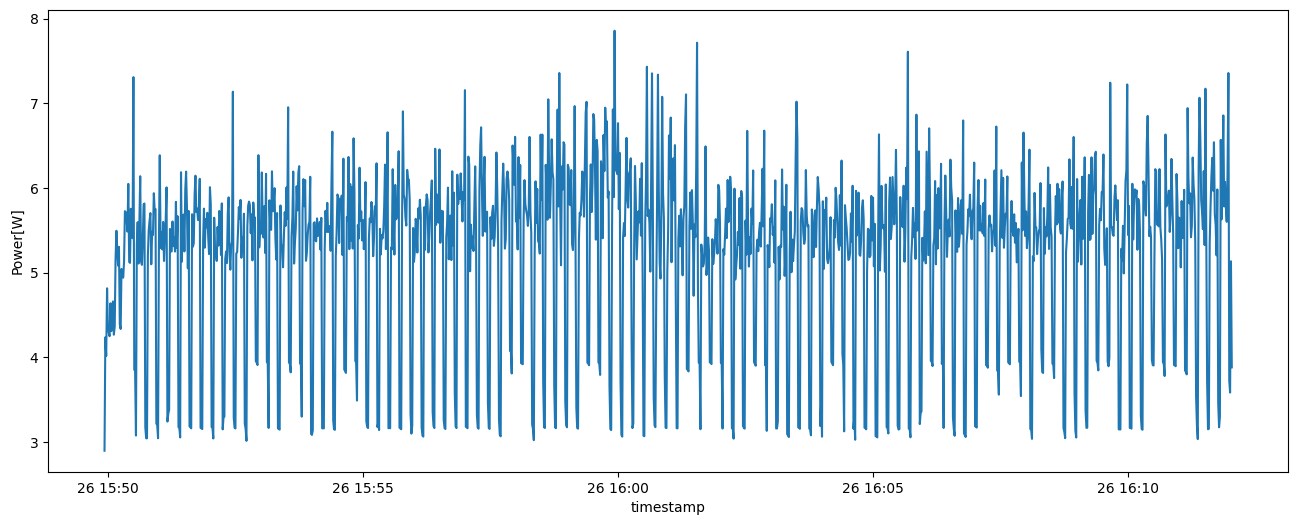

In [21]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx31_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

## X4.0 ~ Mas (Single) | Baseline

passage_time: 10; interval: 3; window: 3

In [59]:
x40_folder_path = '../infra/reports/mas-single_baseline'

### Predict

In [76]:
from pandas import json_normalize
import json

with open(f'{x40_folder_path}/metrics.json') as f:
    x40_data = json.load(f)

load_model_duration = datetime.fromisoformat(x40_data['load_model_final']) - datetime.fromisoformat(x40_data['load_model_start'])
    
rows = []
for animal, v1 in x40_data['animals'].items():
    row_base = {
        'pid': x40_data['pid'],
        'load_model_start': datetime.fromisoformat(x40_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x40_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':9, #v1['total_of_images'],
        'suitable_images':2 #v1['suitable_images'],
    }
    
    for img, v2 in v1['imgs'].items():
        row = row_base.copy()
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx40_metrics_v0 = pd.DataFrame.from_dict(rows)
dx40_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,1,2026-04-26 16:16:44.969309,2026-04-26 16:16:53.991070,2026-04-26 16:16:56.760236,9,2,2026-04-26 16:16:46.411622,2026-04-26 16:16:48.910908
1,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,1,2026-04-26 16:16:44.969309,2026-04-26 16:16:53.991070,2026-04-26 16:16:56.760236,9,2,2026-04-26 16:16:48.479137,2026-04-26 16:16:53.029880
2,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,1,2026-04-26 16:16:44.969309,2026-04-26 16:16:53.991070,2026-04-26 16:16:56.760236,9,2,2026-04-26 16:16:50.506410,2026-04-26 16:16:55.609990
3,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,2,2026-04-26 16:16:59.001813,2026-04-26 16:17:07.013438,2026-04-26 16:17:08.684481,9,2,2026-04-26 16:17:00.179755,2026-04-26 16:17:02.340287
4,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,2,2026-04-26 16:16:59.001813,2026-04-26 16:17:07.013438,2026-04-26 16:17:08.684481,9,2,2026-04-26 16:17:02.269178,2026-04-26 16:17:05.482124


In [77]:
dx40_metrics_v0['img_weight_prediction_dur'] = dx40_metrics_v0['weight_prediction_final'] - dx40_metrics_v0['weight_prediction_start']
dx40_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur
0,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,1,2026-04-26 16:16:44.969309,2026-04-26 16:16:53.991070,2026-04-26 16:16:56.760236,9,2,2026-04-26 16:16:46.411622,2026-04-26 16:16:48.910908,0 days 00:00:02.499286
1,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,1,2026-04-26 16:16:44.969309,2026-04-26 16:16:53.991070,2026-04-26 16:16:56.760236,9,2,2026-04-26 16:16:48.479137,2026-04-26 16:16:53.029880,0 days 00:00:04.550743
2,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,1,2026-04-26 16:16:44.969309,2026-04-26 16:16:53.991070,2026-04-26 16:16:56.760236,9,2,2026-04-26 16:16:50.506410,2026-04-26 16:16:55.609990,0 days 00:00:05.103580
3,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,2,2026-04-26 16:16:59.001813,2026-04-26 16:17:07.013438,2026-04-26 16:17:08.684481,9,2,2026-04-26 16:17:00.179755,2026-04-26 16:17:02.340287,0 days 00:00:02.160532
4,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,2,2026-04-26 16:16:59.001813,2026-04-26 16:17:07.013438,2026-04-26 16:17:08.684481,9,2,2026-04-26 16:17:02.269178,2026-04-26 16:17:05.482124,0 days 00:00:03.212946


In [78]:
by_animal_dict = []

for animal, by_animal in dx40_metrics_v0.groupby('animal'):
    # .max() return the most recent date   
    by_animal_lead_time = by_animal['display_time'].max() - by_animal['first_image_capture_time'].iloc[0]
    by_animal_processing_delay = by_animal['img_weight_prediction_dur'].sum()
    by_animal_latency = by_animal['display_time'].max() - by_animal['last_image_capture_time'].max()
    
    by_animal_dict.append({
        'animal': animal,
        'by_animal_lead_time':by_animal_lead_time,
        'by_animal_processing_delay':by_animal_processing_delay,
        'by_animal_latency':by_animal_latency,
    })

dx40_metrics_v1 = dx40_metrics_v0.merge(
    pd.DataFrame.from_records(by_animal_dict),
    on='animal'
)
dx40_metrics_v1.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,1,2026-04-26 16:16:44.969309,2026-04-26 16:16:53.991070,2026-04-26 16:16:56.760236,9,2,2026-04-26 16:16:46.411622,2026-04-26 16:16:48.910908,0 days 00:00:02.499286,0 days 00:00:11.790927,0 days 00:00:12.153609,0 days 00:00:02.769166
1,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,1,2026-04-26 16:16:44.969309,2026-04-26 16:16:53.991070,2026-04-26 16:16:56.760236,9,2,2026-04-26 16:16:48.479137,2026-04-26 16:16:53.029880,0 days 00:00:04.550743,0 days 00:00:11.790927,0 days 00:00:12.153609,0 days 00:00:02.769166
2,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,1,2026-04-26 16:16:44.969309,2026-04-26 16:16:53.991070,2026-04-26 16:16:56.760236,9,2,2026-04-26 16:16:50.506410,2026-04-26 16:16:55.609990,0 days 00:00:05.103580,0 days 00:00:11.790927,0 days 00:00:12.153609,0 days 00:00:02.769166
3,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,2,2026-04-26 16:16:59.001813,2026-04-26 16:17:07.013438,2026-04-26 16:17:08.684481,9,2,2026-04-26 16:17:00.179755,2026-04-26 16:17:02.340287,0 days 00:00:02.160532,0 days 00:00:09.682668,0 days 00:00:05.373478,0 days 00:00:01.671043
4,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,2,2026-04-26 16:16:59.001813,2026-04-26 16:17:07.013438,2026-04-26 16:17:08.684481,9,2,2026-04-26 16:17:02.269178,2026-04-26 16:17:05.482124,0 days 00:00:03.212946,0 days 00:00:09.682668,0 days 00:00:05.373478,0 days 00:00:01.671043


In [79]:
collect_lead_time = dx40_metrics_v1['display_time'].max() - dx40_metrics_v1['first_image_capture_time'].min()
qtt = len(dx40_metrics_v1['animal'].unique())

dx40_metrics_v1['collect_lead_time'] = collect_lead_time
dx40_metrics_v1['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx40_metrics_v1.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,1,2026-04-26 16:16:44.969309,2026-04-26 16:16:53.991070,2026-04-26 16:16:56.760236,9,2,2026-04-26 16:16:46.411622,2026-04-26 16:16:48.910908,0 days 00:00:02.499286,0 days 00:00:11.790927,0 days 00:00:12.153609,0 days 00:00:02.769166,0 days 00:21:40.196924,276.881135
1,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,1,2026-04-26 16:16:44.969309,2026-04-26 16:16:53.991070,2026-04-26 16:16:56.760236,9,2,2026-04-26 16:16:48.479137,2026-04-26 16:16:53.029880,0 days 00:00:04.550743,0 days 00:00:11.790927,0 days 00:00:12.153609,0 days 00:00:02.769166,0 days 00:21:40.196924,276.881135
2,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,1,2026-04-26 16:16:44.969309,2026-04-26 16:16:53.991070,2026-04-26 16:16:56.760236,9,2,2026-04-26 16:16:50.506410,2026-04-26 16:16:55.609990,0 days 00:00:05.103580,0 days 00:00:11.790927,0 days 00:00:12.153609,0 days 00:00:02.769166,0 days 00:21:40.196924,276.881135
3,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,2,2026-04-26 16:16:59.001813,2026-04-26 16:17:07.013438,2026-04-26 16:17:08.684481,9,2,2026-04-26 16:17:00.179755,2026-04-26 16:17:02.340287,0 days 00:00:02.160532,0 days 00:00:09.682668,0 days 00:00:05.373478,0 days 00:00:01.671043,0 days 00:21:40.196924,276.881135
4,mas-single_2026-04-26T16:16:31.374345,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,2,2026-04-26 16:16:59.001813,2026-04-26 16:17:07.013438,2026-04-26 16:17:08.684481,9,2,2026-04-26 16:17:02.269178,2026-04-26 16:17:05.482124,0 days 00:00:03.212946,0 days 00:00:09.682668,0 days 00:00:05.373478,0 days 00:00:01.671043,0 days 00:21:40.196924,276.881135


In [80]:
dx40_metrics_v1.describe()

,load_model_start,load_model_final,load_model_dur,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,201,201,201,201,201,201,201.0,201.0,201,201,201,201,201,201,201,2.010000e+02
mean,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,2026-04-26 16:27:27.498513,2026-04-26 16:27:35.532693,2026-04-26 16:27:37.236801,9.0,2.0,2026-04-26 16:27:29.760460,2026-04-26 16:27:32.481759,0 days 00:00:02.721298,0 days 00:00:09.738287,0 days 00:00:05.503062,0 days 00:00:01.704108,0 days 00:21:40.196924,2.768811e+02
min,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,2026-04-26 16:16:44.969309,2026-04-26 16:16:53.991070,2026-04-26 16:16:56.760236,9.0,2.0,2026-04-26 16:16:46.411622,2026-04-26 16:16:48.910908,0 days 00:00:01.979717,0 days 00:00:09.631645,0 days 00:00:05.184593,0 days 00:00:01.614910,0 days 00:21:40.196924,2.768811e+02
25%,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,2026-04-26 16:21:58.459874,2026-04-26 16:22:06.474187,2026-04-26 16:22:08.171581,9.0,2.0,2026-04-26 16:22:01.838276,2026-04-26 16:22:05.116216,0 days 00:00:02.142693,0 days 00:00:09.675299,0 days 00:00:05.328581,0 days 00:00:01.660804,0 days 00:21:40.196924,2.768811e+02
50%,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,2026-04-26 16:27:24.185265,2026-04-26 16:27:32.202947,2026-04-26 16:27:33.867966,9.0,2.0,2026-04-26 16:27:27.449820,2026-04-26 16:27:30.674652,0 days 00:00:03.106140,0 days 00:00:09.696995,0 days 00:00:05.381445,0 days 00:00:01.681427,0 days 00:21:40.196924,2.768811e+02
75%,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,2026-04-26 16:32:49.888686,2026-04-26 16:32:57.908587,2026-04-26 16:32:59.593945,9.0,2.0,2026-04-26 16:32:53.193243,2026-04-26 16:32:56.428927,0 days 00:00:03.227868,0 days 00:00:09.724824,0 days 00:00:05.464130,0 days 00:00:01.710364,0 days 00:21:40.196924,2.768811e+02
max,2026-04-26 16:16:32.959163,2026-04-26 16:16:44.101938,0 days 00:00:11.142775,2026-04-26 16:38:15.425818,2026-04-26 16:38:23.441786,2026-04-26 16:38:25.166233,9.0,2.0,2026-04-26 16:38:18.759782,2026-04-26 16:38:21.998954,0 days 00:00:05.103580,0 days 00:00:11.790927,0 days 00:00:12.153609,0 days 00:00:02.769166,0 days 00:21:40.196924,2.768811e+02
std,NaN,NaN,0 days 00:00:00,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0 days 00:00:00.588185,0 days 00:00:00.261882,0 days 00:00:00.831146,0 days 00:00:00.142845,0 days 00:00:00,5.698535e-14


In [104]:
dx40_metrics_v1.groupby('animal')['by_animal_processing_delay'].sum().reset_index(name='time')['time'].sum()

Timedelta('0 days 00:18:26.115625')

In [82]:
total_of_imgs = len(dx40_metrics_v1['animal'].unique()) * 9 #dx10_metrics_v1.groupby('animal')['total_of_images'].size().reset_index(name='qtd')['qtd'].sum()
total_time = pd.to_timedelta(dx40_metrics_v1['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 900 - Time: 0 days 00:21:40.196924 => FPS:0.6922028374218796


### CPU

In [152]:
dx40_cpu = pd.read_csv(f'{x40_folder_path}/cpu.csv')

dx40_cpu['arch-str']  = 'agt-batch'
dx40_cpu['timestamp'] = dx40_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx40_cpu['cpu_mean']  = dx40_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx40_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,arch-str,cpu_mean
0,2026-04-26 16:16:33.959116,53.1,16.0,13.7,46.5,agt-batch,32.325
1,2026-04-26 16:16:34.960474,18.0,60.0,29.3,30.0,agt-batch,34.325
2,2026-04-26 16:16:35.969268,46.4,45.0,39.2,34.3,agt-batch,41.225
3,2026-04-26 16:16:36.970837,56.9,5.0,8.8,54.2,agt-batch,31.225
4,2026-04-26 16:16:37.973443,68.7,1.0,0.0,71.7,agt-batch,35.350


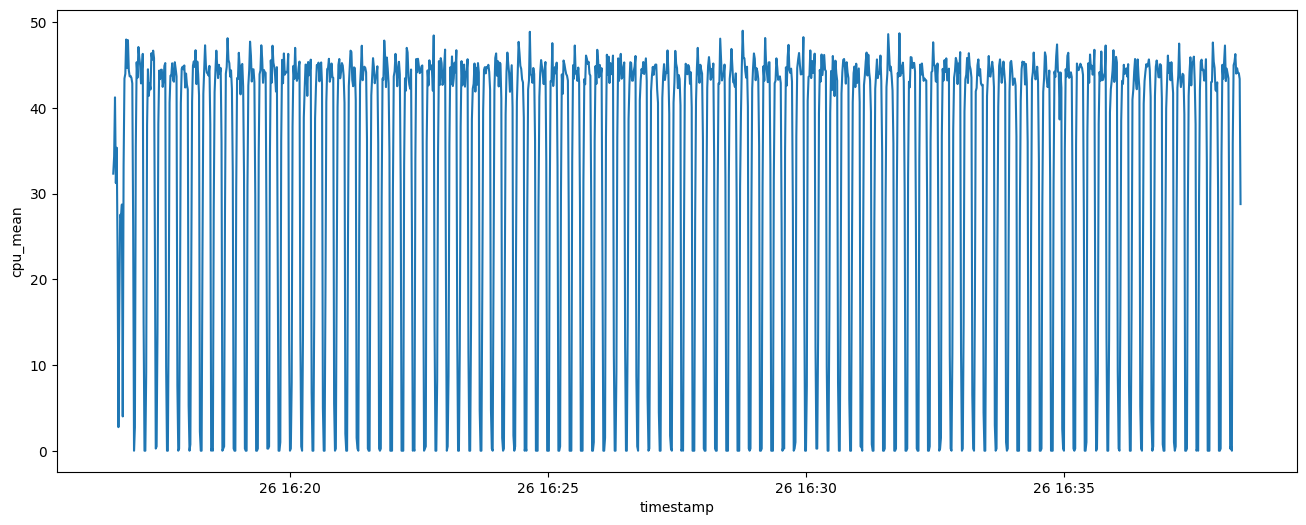

In [64]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx40_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

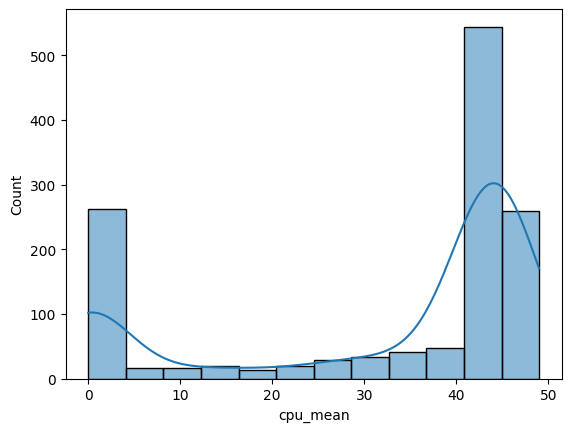

In [65]:
sns.histplot(data=dx40_cpu, x="cpu_mean", kde=True)
plt.show()

In [66]:
dx40_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1303,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000
mean,2026-04-26 16:27:29.792736,32.411589,32.210054,32.622717,31.742210,32.246642
min,2026-04-26 16:16:33.959116,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-04-26 16:22:01.807077,15.650000,14.500000,15.000000,15.100000,19.675000
50%,2026-04-26 16:27:29.842271,40.200000,40.200000,40.600000,40.000000,43.100000
75%,2026-04-26 16:32:57.764210,44.900000,44.700000,45.100000,43.950000,44.625000
max,2026-04-26 16:38:25.459303,78.800000,68.000000,80.000000,71.700000,49.000000
std,NaN,19.330441,19.328738,19.502538,18.914862,18.006217


In [107]:
threshold = dx40_cpu['cpu_mean'].quantile(0.75)
dx40_cpu[dx40_cpu['cpu_mean'] > threshold].describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,321,321.000000,321.000000,321.000000,321.000000,321.000000
mean,2026-04-26 16:27:10.618166,45.217445,46.343614,45.745171,45.261994,45.642056
min,2026-04-26 16:16:48.996228,35.400000,33.300000,34.700000,33.700000,44.650000
25%,2026-04-26 16:21:50.246047,41.400000,42.200000,42.000000,41.800000,44.975000
50%,2026-04-26 16:26:52.608485,43.600000,44.600000,44.000000,43.800000,45.350000
75%,2026-04-26 16:32:14.776649,47.100000,51.500000,50.000000,47.100000,46.050000
max,2026-04-26 16:38:19.415956,61.600000,60.200000,62.400000,59.400000,49.000000
std,NaN,5.252488,5.782217,5.238468,5.206413,0.893317


### RAM

In [67]:
dx40_ram = pd.read_csv(f'{x40_folder_path}/mem.csv')
dx40_ram['timestamp'] = dx40_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx40_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-26 16:16:32.957116,17002643456,16314351616,688291840,4.0,15702835200,770637824,208388096,42287104,688570368
1,2026-04-26 16:16:33.959200,17002643456,16280846336,721797120,4.2,15666085888,800423936,209567744,42401792,691372032
2,2026-04-26 16:16:34.960559,17002643456,16240295936,762347520,4.5,15625535488,846135296,209567744,42401792,691372032
3,2026-04-26 16:16:35.961865,17002643456,16150462464,852180992,5.0,15535702016,931954688,209567744,42401792,691372032
4,2026-04-26 16:16:36.962986,17002643456,16144695296,857948160,5.0,15529803776,939868160,209567744,42401792,691503104


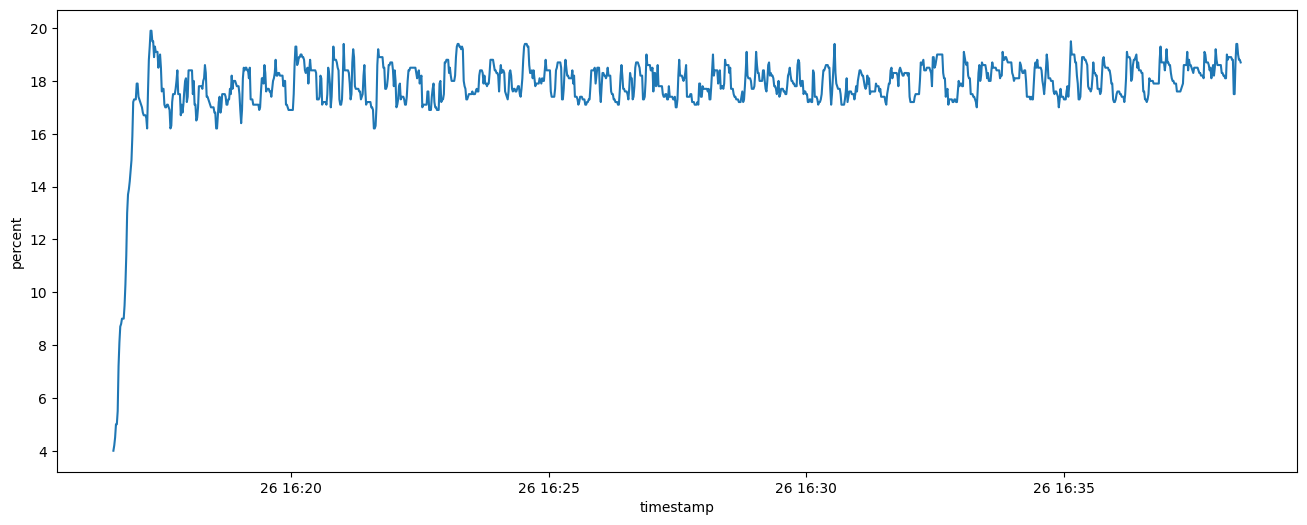

In [68]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx40_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

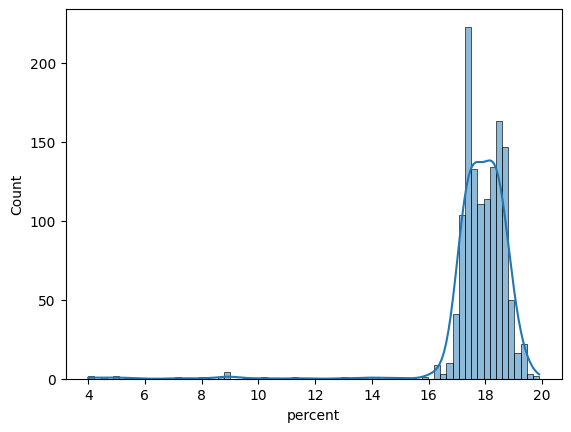

In [69]:
sns.histplot(data=dx40_ram, x="percent", kde=True)
plt.show()

In [70]:
dx40_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,1308,1.308000e+03,1.308000e+03,1.308000e+03,1308.000000,1.308000e+03,1.308000e+03,1.308000e+03,1.308000e+03,1.308000e+03
mean,2026-04-26 16:27:29.757631,1.700264e+10,1.397348e+10,3.029160e+09,17.816055,1.319723e+10,3.166891e+09,3.671143e+08,4.258485e+07,8.528063e+08
min,2026-04-26 16:16:32.957116,1.700264e+10,1.361720e+10,6.882918e+08,4.000000,1.284024e+10,7.706378e+08,2.083881e+08,4.228710e+07,6.885704e+08
25%,2026-04-26 16:22:01.455752,1.700264e+10,1.386970e+10,2.964419e+09,17.400000,1.309245e+10,3.120251e+09,3.678208e+08,4.243456e+07,8.536556e+08
50%,2026-04-26 16:27:29.664101,1.700264e+10,1.395127e+10,3.051373e+09,17.900000,1.317401e+10,3.196502e+09,3.678372e+08,4.245094e+07,8.536556e+08
75%,2026-04-26 16:32:58.055098,1.700264e+10,1.403822e+10,3.132944e+09,18.400000,1.326095e+10,3.273867e+09,3.681649e+08,4.277862e+07,8.537702e+08
max,2026-04-26 16:38:26.325042,1.700264e+10,1.631435e+10,3.385442e+09,19.900000,1.570284e+10,3.442278e+09,3.681812e+08,4.279501e+07,8.539341e+08
std,NaN,0.000000e+00,2.314638e+08,2.314638e+08,1.361927,2.399442e+08,2.425785e+08,1.131126e+07,1.708942e+05,1.161728e+07


In [108]:
threshold = dx40_ram['percent'].quantile(0.75)
dx40_ram[dx40_ram['percent'] > threshold].describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,305,3.050000e+02,3.050000e+02,3.050000e+02,305.000000,3.050000e+02,3.050000e+02,3.050000e+02,3.050000e+02,3.050000e+02
mean,2026-04-26 16:29:31.983079,1.700264e+10,1.381015e+10,3.192493e+09,18.777049,1.303295e+10,3.309580e+09,3.680151e+08,4.262988e+07,8.537203e+08
min,2026-04-26 16:17:14.274383,1.700264e+10,1.361720e+10,3.137241e+09,18.500000,1.284024e+10,3.183690e+09,3.678208e+08,4.243456e+07,8.533770e+08
25%,2026-04-26 16:23:13.081147,1.700264e+10,1.378856e+10,3.156427e+09,18.600000,1.301155e+10,3.274473e+09,3.678208e+08,4.243456e+07,8.536556e+08
50%,2026-04-26 16:31:39.506280,1.700264e+10,1.382190e+10,3.180741e+09,18.700000,1.304450e+10,3.308323e+09,3.681649e+08,4.277862e+07,8.537702e+08
75%,2026-04-26 16:35:34.637696,1.700264e+10,1.384622e+10,3.214082e+09,18.900000,1.306885e+10,3.337404e+09,3.681812e+08,4.279501e+07,8.537866e+08
max,2026-04-26 16:38:26.325042,1.700264e+10,1.386540e+10,3.385442e+09,19.900000,1.308800e+10,3.442278e+09,3.681812e+08,4.279501e+07,8.539341e+08
std,NaN,0.000000e+00,4.591109e+07,4.591109e+07,0.267784,4.588239e+07,4.844829e+07,1.740500e+05,1.739160e+05,6.794568e+04


### Power

In [71]:
dx40_power = pd.read_csv(f'{x40_folder_path}/power.csv')
dx40_power['timestamp'] = dx40_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx40_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-29T07:53:00.911156,0.0,5.1097,0.42627,2.1739,2026-04-29 07:53:00.911156
1,2026-04-29T07:53:01.926195,1.0,5.1059,0.57754,2.9454,2026-04-29 07:53:01.926195
2,2026-04-29T07:53:02.941348,2.0,5.1097,0.65374,3.3340,2026-04-29 07:53:02.941348
3,2026-04-29T07:53:03.910799,3.0,5.1095,0.70182,3.5792,2026-04-29 07:53:03.910799
4,2026-04-29T07:53:04.928035,4.0,5.1092,0.70960,3.6189,2026-04-29 07:53:04.928035


In [72]:
dx40_power = dx40_power.sort_values('timestamp')

# Time difference in hours
dx40_power['dt_hours'] = dx40_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx40_power['energy_Wh'] = dx40_power['Power[W]'] * dx40_power['dt_hours']

# Total energy
total_energy_Wh = dx40_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.76980364932
Total energy (kWh): 0.00176980364932


In [73]:
dx40_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,1330.000000,1330.000000,1330.000000,1330.000000,1330,1329.000000,1329.000000
mean,664.586316,5.107760,0.939141,4.791419,2026-04-29 08:04:05.510965,0.000278,0.001332
min,0.000000,5.076400,0.426270,2.173900,2026-04-29 07:53:00.911156,0.000269,0.000657
25%,332.250000,5.105800,0.698780,3.565450,2026-04-29 07:58:33.202609,0.000271,0.001004
50%,664.600000,5.108500,1.018145,5.192800,2026-04-29 08:04:05.504911,0.000283,0.001440
75%,996.850000,5.110300,1.110330,5.664825,2026-04-29 08:09:37.786199,0.000283,0.001571
max,1329.200000,5.123100,1.555280,7.931900,2026-04-29 08:15:10.099758,0.000285,0.002242
std,384.138666,0.005289,0.247022,1.260015,NaN,0.000006,0.000351


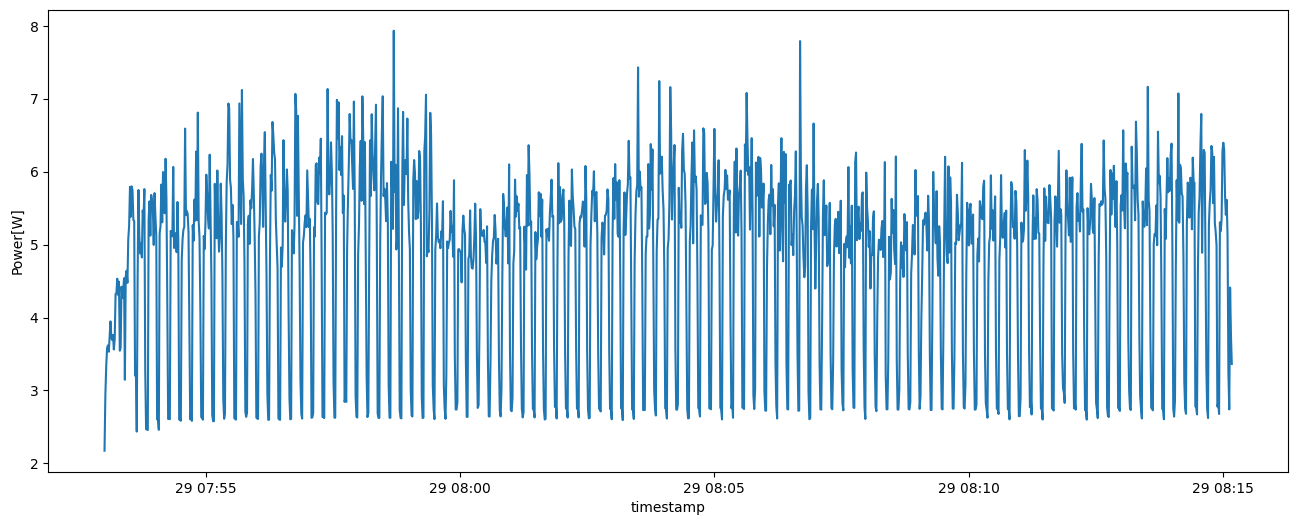

In [74]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx40_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

# Charts

In [230]:
window_size = 15

## CPU

In [202]:
dx10_cpu_w = dx10_cpu[['cpu_mean']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).mean().dropna()

dx10_cpu_w['arch-str'] = 'seq-single'
dx10_cpu_w.shape

(112, 2)

In [198]:
dx20_cpu_w = dx20_cpu[['cpu_mean']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).mean().dropna()

dx20_cpu_w['arch-str'] = 'seq-batch'
dx20_cpu_w.shape

(126, 2)

In [199]:
dx30_cpu_w = dx31_cpu[['cpu_mean']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).mean().dropna()

dx30_cpu_w['arch-str'] = 'agt-single'
dx30_cpu_w.shape

(108, 2)

In [200]:
dx40_cpu_w = dx40_cpu[['cpu_mean']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).mean().dropna()

dx40_cpu_w['arch-str'] = 'agt-batch'
dx40_cpu_w.shape

(108, 2)

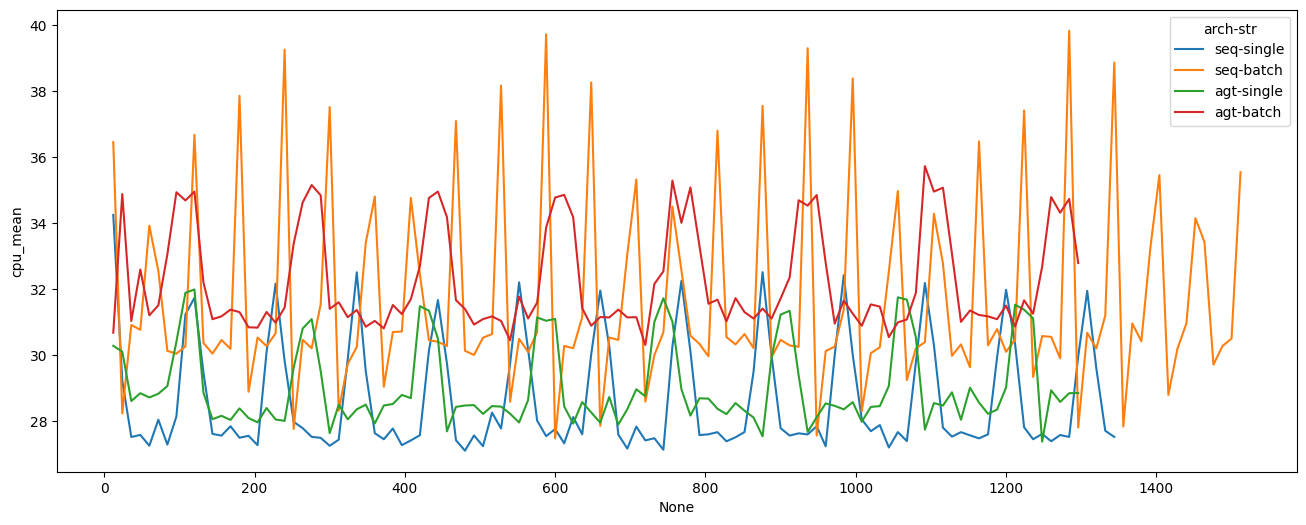

In [201]:
dall_cpu = pd.concat([dx10_cpu_w, dx20_cpu_w, dx30_cpu_w, dx40_cpu_w])
dall_cpu.sort_index().head()

plt.figure(figsize=(16, 6))
sns.lineplot(data=dall_cpu, x=dall_cpu.index, y="cpu_mean", hue='arch-str')
plt.show()

## RAM

In [204]:
dx10_ram_w = dx10_ram[['percent']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).mean().dropna()

dx10_ram_w['arch-str'] = 'seq-single'
dx10_ram_w.shape

(112, 2)

In [206]:
dx20_ram_w = dx20_ram[['percent']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).mean().dropna()

dx20_ram_w['arch-str'] = 'seq-batch'
dx20_ram_w.shape

(126, 2)

In [207]:
dx30_ram_w = dx31_ram[['percent']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).mean().dropna()

dx30_ram_w['arch-str'] = 'agt-single'
dx30_ram_w.shape

(108, 2)

In [208]:
dx40_ram_w = dx40_ram[['percent']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).mean().dropna()

dx40_ram_w['arch-str'] = 'agt-batch'
dx40_ram_w.shape

(108, 2)

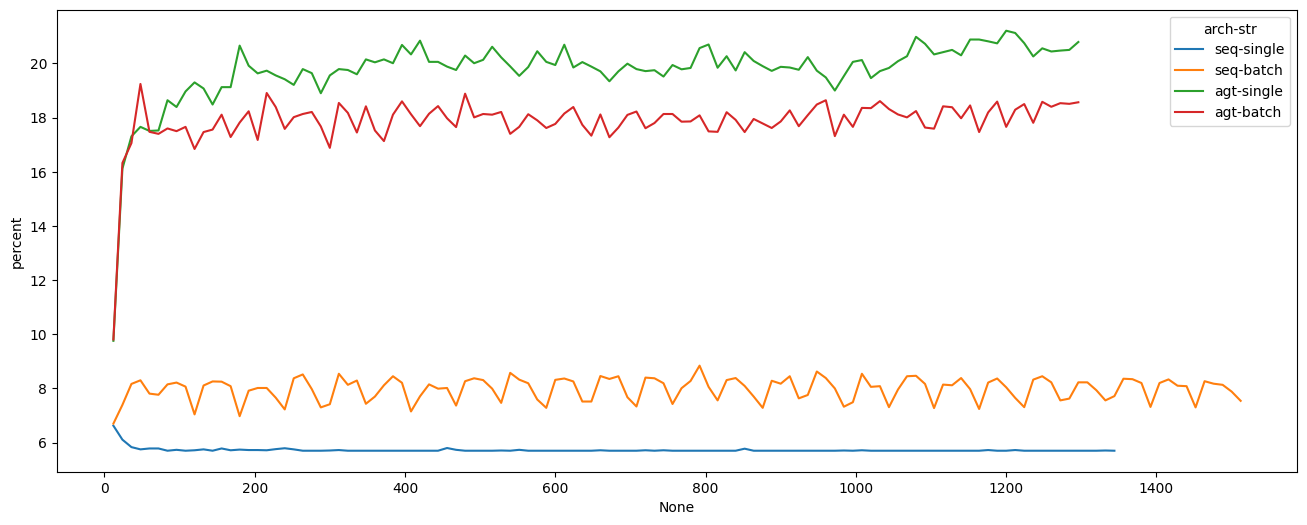

In [222]:
dall_ram = pd.concat([dx10_ram_w, dx20_ram_w, dx30_ram_w, dx40_ram_w])
dall_ram.sort_index().head()

plt.figure(figsize=(16, 6))
sns.lineplot(data=dall_ram, x=dall_ram.index, y="percent", hue='arch-str')
plt.show()

## POWER

In [231]:
dx10_power_w = dx10_power[['Power[W]']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).mean().dropna()

dx10_power_w['arch-str'] = 'seq-single'
dx10_power_w.shape

(91, 2)

In [232]:
dx20_power_w = dx20_power[['Power[W]']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).mean().dropna()

dx20_power_w['arch-str'] = 'seq-batch'
dx20_power_w.shape

(102, 2)

In [233]:
dx30_power_w = dx31_power[['Power[W]']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).mean().dropna()

dx30_power_w['arch-str'] = 'agt-single'
dx30_power_w.shape

(87, 2)

In [234]:
dx40_power_w = dx40_power[['Power[W]']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).mean().dropna()

dx40_power_w['arch-str'] = 'agt-batch'
dx40_power_w.shape

(88, 2)

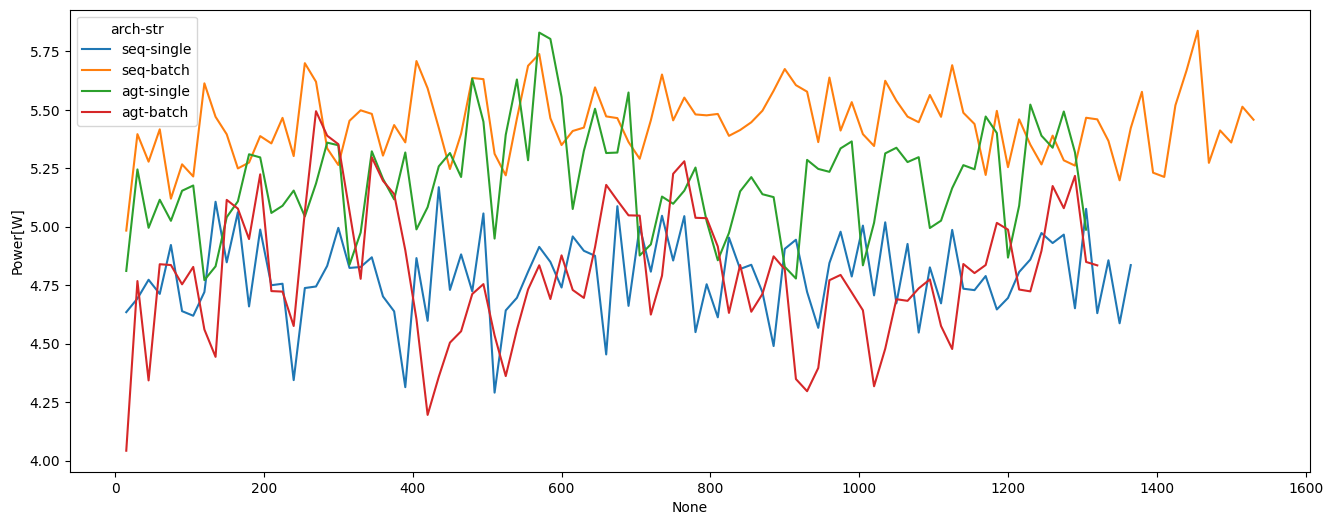

In [235]:
dall_power = pd.concat([dx10_power_w, dx20_power_w, dx30_power_w, dx40_power_w])
dall_power.sort_index().head()

plt.figure(figsize=(16, 6))
sns.lineplot(data=dall_power, x=dall_power.index, y="Power[W]", hue='arch-str')
plt.show()